In [80]:
# Install dependencies
!pip install -q sentence-transformers faiss-cpu umap-learn matplotlib seaborn scikit-learn rank-bm25 tabulate rouge-score bert-score

In [81]:
%cd /content
!rm -rf agriculture-rag-chatbot
!git clone https://github.com/Prathameshkadam1998/agriculture-rag-chatbot.git
%cd agriculture-rag-chatbot

/content
Cloning into 'agriculture-rag-chatbot'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 64 (delta 28), reused 20 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 22.56 KiB | 4.51 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/agriculture-rag-chatbot


In [82]:
import sys
from pathlib import Path

if Path("src/config.py").exists():
    sys.path.append("src")
elif Path("../src/config.py").exists():
    sys.path.append("../src")
else:
    raise FileNotFoundError("Could not find src/config.py")

print("Using config from:", sys.path[-1])

Using config from: src


In [83]:
!git pull

Already up to date.


In [84]:
!pwd
!ls
!ls src

/content/agriculture-rag-chatbot
data  models  notebooks  README.md  reports  requirements.txt  scripts	src
config.py	    generation.py  pipeline.py
data_processing.py  __init__.py    retrieval.py


In [85]:
import sys
from pathlib import Path
import importlib

SRC_PATH = Path.cwd() / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

importlib.invalidate_caches()

print("Current folder:", Path.cwd())
print("Using src path:", SRC_PATH)
print("pipeline exists:", (SRC_PATH / "pipeline.py").exists())

Current folder: /content/agriculture-rag-chatbot
Using src path: /content/agriculture-rag-chatbot/src
pipeline exists: True


In [86]:
# Imports
import re
import math
import time
import hashlib
import random
import json
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
import torch
import nltk
import umap

from tqdm import tqdm
from collections import Counter, defaultdict
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer, CrossEncoder, InputExample
from sklearn.metrics.pairwise import cosine_similarity
from datasets import load_dataset
from tabulate import tabulate
from rank_bm25 import BM25Okapi
from torch.utils.data import DataLoader
from config import (
    DATASET_NAME,
    CHUNK_SIZE,
    CHUNK_OVERLAP,
    MAX_SENTENCES,
    OVERLAP_SENTENCES,
    TOP_K_SEMANTIC,
    TOP_K_BM25,
    RRF_K,
    FINAL_TOP_K,
    EMBEDDING_MODEL_NAME,
    CROSS_ENCODER_MODEL_NAME,
    GENERATOR_MODEL_NAME,
    MAX_CONTEXT_WORDS,
    MAX_NEW_TOKENS,
    GENERATION_NUM_BEAMS,
    GENERATION_NO_REPEAT_NGRAM_SIZE,
    GENERATION_LENGTH_PENALTY,
    EVAL_SIZE,
    K_VALUES,
    EMBEDDING_MODELS,
    CROSS_ENCODER_BASE,
    CROSS_ENCODER_SAVE_DIR,
    EMBEDDINGS_SAVE_PATH,
    GENERATOR_MODEL,
    MAX_CONTEXT_TOKENS,
    EMBEDDING_BATCH_SIZE,
    EMBEDDING_SAMPLE_SIZE,
    FINETUNE_BATCH_SIZE,
    FINETUNE_EPOCHS,
    EVAL_TEST_SIZE,
    GEN_EVAL_SIZE,
    TEST_QUERIES,
    DOMAIN_STOPWORDS,
    QUERY_EXPANSIONS,
    TOPIC_KEYWORDS,
    TOPIC_COLORS,
    TOPIC_QUERIES,
)
from pipeline import AgriRAGPipeline, SemanticOnlyPipeline, HybridCEPipeline

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

random.seed(42)
np.random.seed(42)

In [87]:
from datasets import load_dataset
dataset = load_dataset("KisanVaani/agriculture-qa-english-only")

print(dataset)

df = pd.DataFrame(dataset["train"])

print(f"\nTotal records: {len(df)}")
print(df.head())
print(f"\nColumns: {df.columns.tolist()}")

DatasetDict({
    train: Dataset({
        features: ['question', 'answers'],
        num_rows: 22615
    })
})

Total records: 22615
                                            question  \
0         why is crop rotation important in farming?   
1  What farming practice helps prevent soil erosion?   
2                              what is crop rotation   
3      what are the different methods of irrigation?   
4                          why is soil health vital?   

                                             answers  
0  This helps to prevent soil erosion and depleti...  
1                                      Crop Rotation  
2  Crop rotation is the practice of growing a ser...  
3  surface irrigation, drip irrigation, and sprin...  
4  Soil health is critical to crop growth and pro...  

Columns: ['question', 'answers']


In [88]:
# =========================
# Text Cleaning
# =========================

from nltk.corpus import stopwords

generic_stopwords = set(stopwords.words("english"))

important_words = {"no", "not", "nor","against"}
generic_stopwords = generic_stopwords - important_words

domain_stopwords = {
    "please", "tell", "give"
}

bm25_stopwords = generic_stopwords | domain_stopwords


def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z0-9\s.,?!]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def remove_stopwords_for_bm25(text):
    text = clean_text(text)
    tokens = text.split()
    tokens = [token for token in tokens if token not in bm25_stopwords]
    return " ".join(tokens)


df["clean_question"] = df["question"].apply(clean_text)
df["clean_answer"] = df["answers"].apply(clean_text)

df["text_for_embedding"] = (
    "question: "
    + df["clean_question"].fillna("")
    + "\nanswer: "
    + df["clean_answer"].fillna("")
)

df["text_for_bm25"] = df["text_for_embedding"].apply(remove_stopwords_for_bm25)

table = df[
    ["question", "clean_question", "clean_answer", "text_for_embedding", "text_for_bm25"]
].head(3)

print(tabulate(table, headers="keys", tablefmt="grid"))

+----+---------------------------------------------------+---------------------------------------------------+------------------------------------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------+
|    | question                                          | clean_question                                    | clean_answer                                                                                               | text_for_embedding                                                                                                 | text_for_bm25                                                                                                           |
+====+===================================================+========================

In [89]:
# Domain stopword analysis
print("Domain-Specific Stopword & Noise Analysis")

all_words = " ".join(df['clean_answer'].tolist()).split()
word_freq = Counter(all_words)

print("\nTop 40 most frequent words in answers:")
for word, count in word_freq.most_common(40):
    print(f"  '{word}': {count}")



Domain-Specific Stopword & Noise Analysis

Top 40 most frequent words in answers:
  'and': 27308
  'the': 24129
  'to': 16333
  'of': 13315
  'can': 8141
  'a': 8123
  'in': 7781
  'soil': 7062
  'or': 6702
  'is': 6645
  'for': 6259
  'as': 4864
  'are': 4370
  'that': 3983
  'with': 3296
  'by': 3072
  'it': 3058
  'be': 2873
  'on': 2833
  'cassava': 2770
  'such': 2754
  'maize': 2634
  'plant': 2477
  'which': 2398
  'crop': 2351
  'water': 2322
  'plants': 2259
  'from': 2085
  'this': 2064
  'organic': 2008
  'disease': 1999
  'nutrient': 1755
  'they': 1647
  'planting': 1632
  'growth': 1614
  'use': 1596
  'help': 1579
  'beans': 1541
  'reduce': 1515
  'crops': 1504


In [90]:
# Build stopword lists and create BM25-specific text
generic_nltk_stopwords = set(stopwords.words('english'))
super_stopwords_list = generic_nltk_stopwords | DOMAIN_STOPWORDS

print(f"Generic NLTK stopwords: {len(generic_nltk_stopwords)}")
print(f"Domain-specific additions: {len(DOMAIN_STOPWORDS)}")
print(f"Total stopwords: {len(super_stopwords_list)}")

def remove_domain_stopwords(text, stopword_set):
    if not isinstance(text, str):
        return ""
    text = clean_text(text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    return ' '.join([w for w in tokens if w not in stopword_set])

# BM25 text: stopwords removed from question + answer text
df['text_for_bm25'] = df['text_for_embedding'].apply(
    lambda x: remove_domain_stopwords(x, super_stopwords_list)
)

sample = df.iloc[1]

print(f"\nEmbedding text ({len(sample['text_for_embedding'].split())} words): "
      f"{sample['text_for_embedding'][:300]}")

print(f"BM25 text ({len(sample['text_for_bm25'].split())} words): "
      f"{sample['text_for_bm25'][:300]}")

Generic NLTK stopwords: 198
Domain-specific additions: 12
Total stopwords: 210

Embedding text (11 words): question: what farming practice helps prevent soil erosion?
answer: crop rotation
BM25 text (7 words): farming practice helps prevent erosion crop rotation


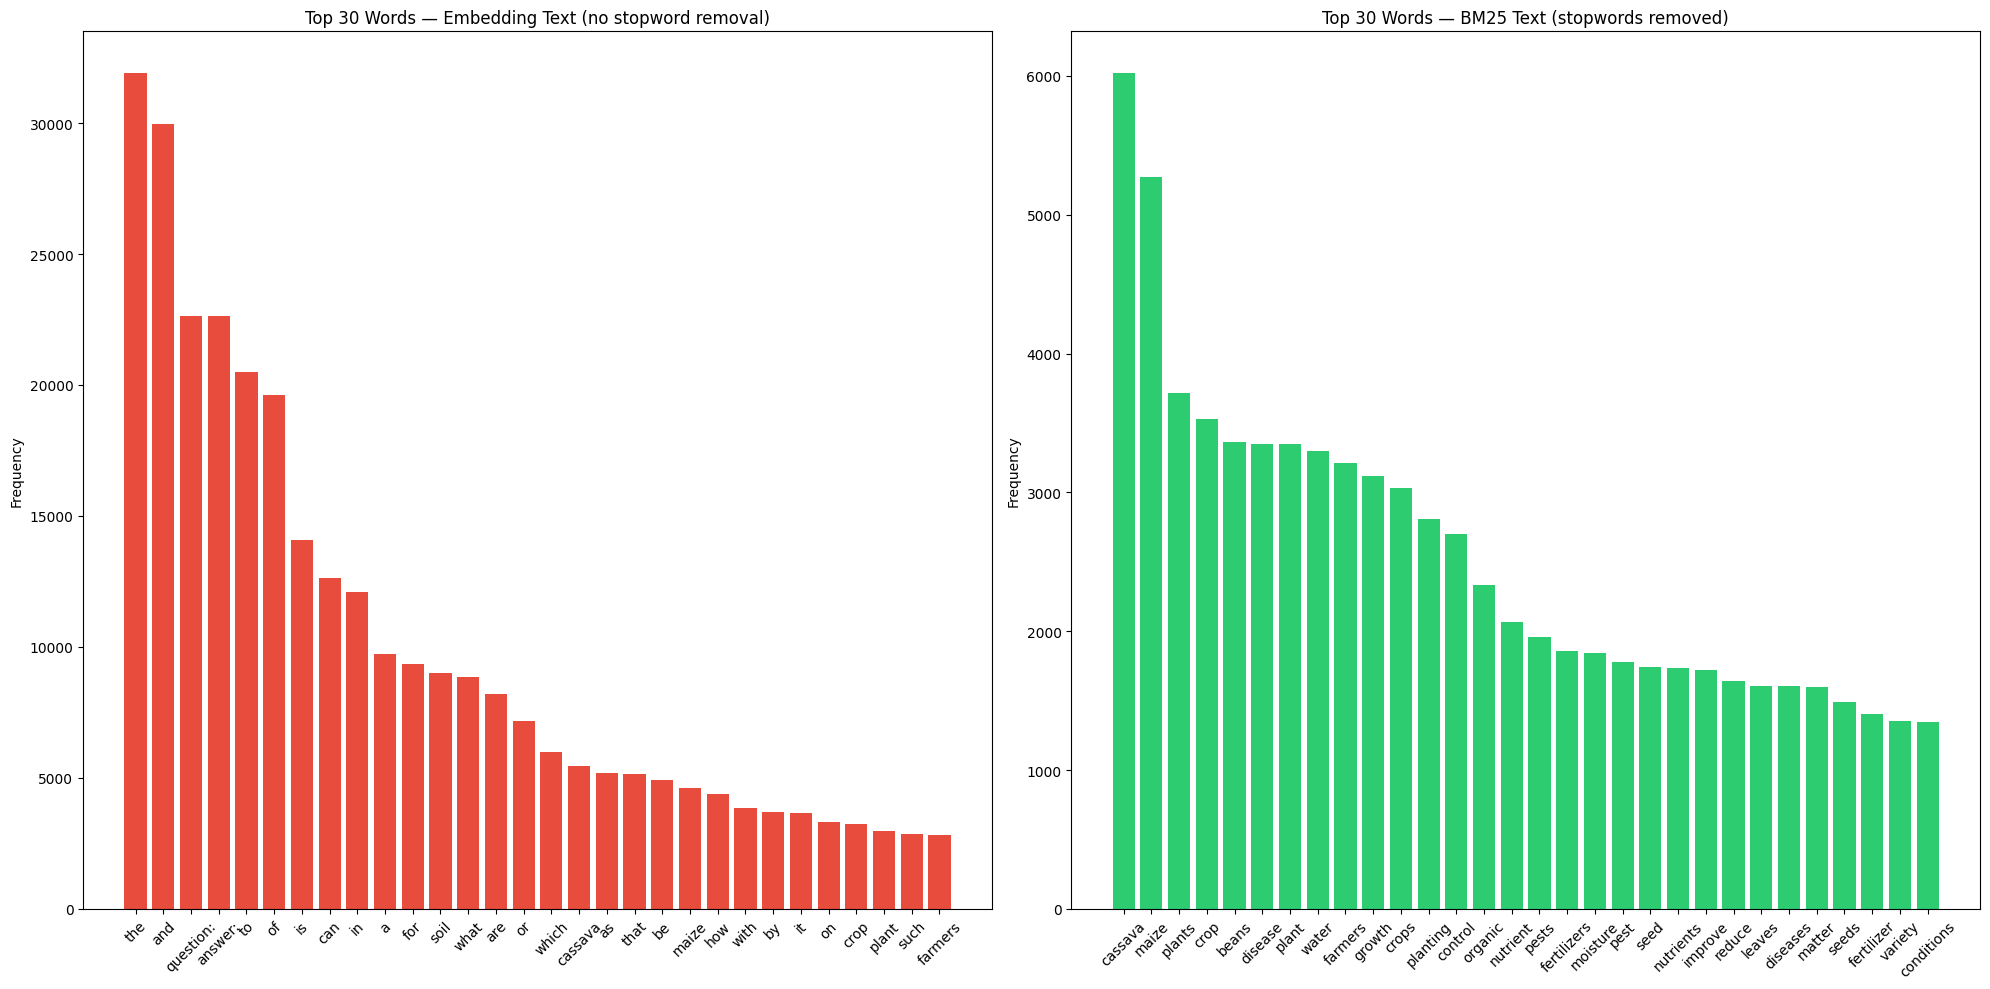

In [91]:
# Visualise stopword impact
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

before_freq = Counter(" ".join(df['text_for_embedding']).split())
before_top = dict(before_freq.most_common(30))
axes[0].bar(before_top.keys(), before_top.values(), color='#e74c3c')
axes[0].set_title('Top 30 Words — Embedding Text (no stopword removal)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Frequency')

after_freq = Counter(" ".join(df['text_for_bm25']).split())
after_top = dict(after_freq.most_common(30))
axes[1].bar(after_top.keys(), after_top.values(), color='#2ecc71')
axes[1].set_title('Top 30 Words — BM25 Text (stopwords removed)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('stopword_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [92]:
# Define chunking strategies

def chunk_word_based(text, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    if not isinstance(text, str) or not text.strip():
        return []

    if overlap >= chunk_size:
        raise ValueError("overlap must be smaller than chunk_size")

    words = text.split()

    if len(words) <= chunk_size:
        return [text]

    chunks = []
    start = 0

    while start < len(words):
        chunk = " ".join(words[start:start + chunk_size]).strip()

        if chunk:
            chunks.append(chunk)

        start += chunk_size - overlap

    return chunks


def chunk_sentence_based(text, max_sentences=MAX_SENTENCES, overlap_sentences=OVERLAP_SENTENCES):
    if not isinstance(text, str) or not text.strip():
        return []

    if overlap_sentences >= max_sentences:
        raise ValueError("overlap_sentences must be smaller than max_sentences")

    sentences = sent_tokenize(text)

    if len(sentences) <= max_sentences:
        return [text]

    chunks = []
    start = 0

    while start < len(sentences):
        chunk = " ".join(sentences[start:start + max_sentences]).strip()

        if chunk:
            chunks.append(chunk)

        start += max_sentences - overlap_sentences

    return chunks


def chunk_recursive(text, chunk_size=CHUNK_SIZE):
    if not isinstance(text, str) or not text.strip():
        return []

    sentences = sent_tokenize(text)

    if len(sentences) > 1:
        return chunk_sentence_based(text)

    return chunk_word_based(text)


print("Chunking strategies defined.")

Chunking strategies defined.


In [93]:
# =========================
# Build and Compare Chunks
# =========================

def build_chunks(strategy_fn, strategy_name, df, text_col):
    chunks, metadata, seen = [], [], set()

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=strategy_name):
        text = row[text_col]

        for chunk in strategy_fn(text):
            h = hashlib.md5(chunk.strip().lower().encode()).hexdigest()

            if h in seen:
                continue

            seen.add(h)

            chunks.append(chunk)

            metadata.append({
                "chunk_id": len(metadata),
                "original_question": row["question"],
                "original_answer": row["answers"],
                "source_row": idx,
            })

    return chunks, metadata


def build_aligned_chunk_sets(strategy_fn, strategy_name, df):
    emb_chunks, bm25_chunks, metadata, seen = [], [], [], set()

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=strategy_name):
        emb_text = row["text_for_embedding"]

        for emb_chunk in strategy_fn(emb_text):
            h = hashlib.md5(emb_chunk.strip().lower().encode()).hexdigest()

            if h in seen:
                continue

            seen.add(h)

            bm25_chunk = remove_domain_stopwords(
                emb_chunk,
                super_stopwords_list
            )

            chunk_id = len(metadata)

            emb_chunks.append(emb_chunk)
            bm25_chunks.append(bm25_chunk)

            metadata.append({
                "chunk_id": chunk_id,
                "original_question": row["question"],
                "original_answer": row["answers"],
                "source_row": idx,
                "embedding_chunk": emb_chunk,
                "bm25_chunk": bm25_chunk,
            })

    return emb_chunks, bm25_chunks, metadata


print("Chunking with all 3 strategies for comparison...")

chunks_word, _ = build_chunks(
    chunk_word_based,
    "Word-based",
    df,
    "text_for_embedding"
)

chunks_sentence, _ = build_chunks(
    chunk_sentence_based,
    "Sentence-based",
    df,
    "text_for_embedding"
)

chunks_recursive, _ = build_chunks(
    chunk_recursive,
    "Recursive",
    df,
    "text_for_embedding"
)

print("\nChunk Count Comparison:")
print(f"Word-based     : {len(chunks_word):,} unique chunks")
print(f"Sentence-based : {len(chunks_sentence):,} unique chunks")
print(f"Recursive      : {len(chunks_recursive):,} unique chunks")

Chunking with all 3 strategies for comparison...


Recursive: 100%|██████████| 22615/22615 [00:09<00:00, 2287.02it/s]


Chunk Count Comparison:
Word-based     : 2,427 unique chunks
Sentence-based : 2,619 unique chunks
Recursive      : 2,619 unique chunks


In [94]:
final_emb_chunks, final_bm25_chunks, final_meta = build_aligned_chunk_sets(
    chunk_sentence_based,
    "Sentence-based final",
    df
)

print(f"\nFinal embedding chunks: {len(final_emb_chunks):,}")
print(f"Final BM25 chunks     : {len(final_bm25_chunks):,}")
print(f"Final metadata rows   : {len(final_meta):,}")

print("\nExample embedding chunk:")
print(final_emb_chunks[0])

print("\nExample BM25 chunk:")
print(final_bm25_chunks[0])

Sentence-based final: 100%|██████████| 22615/22615 [00:07<00:00, 3208.30it/s]


Final embedding chunks: 2,619
Final BM25 chunks     : 2,619
Final metadata rows   : 2,619

Example embedding chunk:
question: why is crop rotation important in farming?
answer: this helps to prevent soil erosion and depletion, and can also help to control pests and diseases

Example BM25 chunk:
crop rotation important farming helps prevent erosion depletion control pests diseases


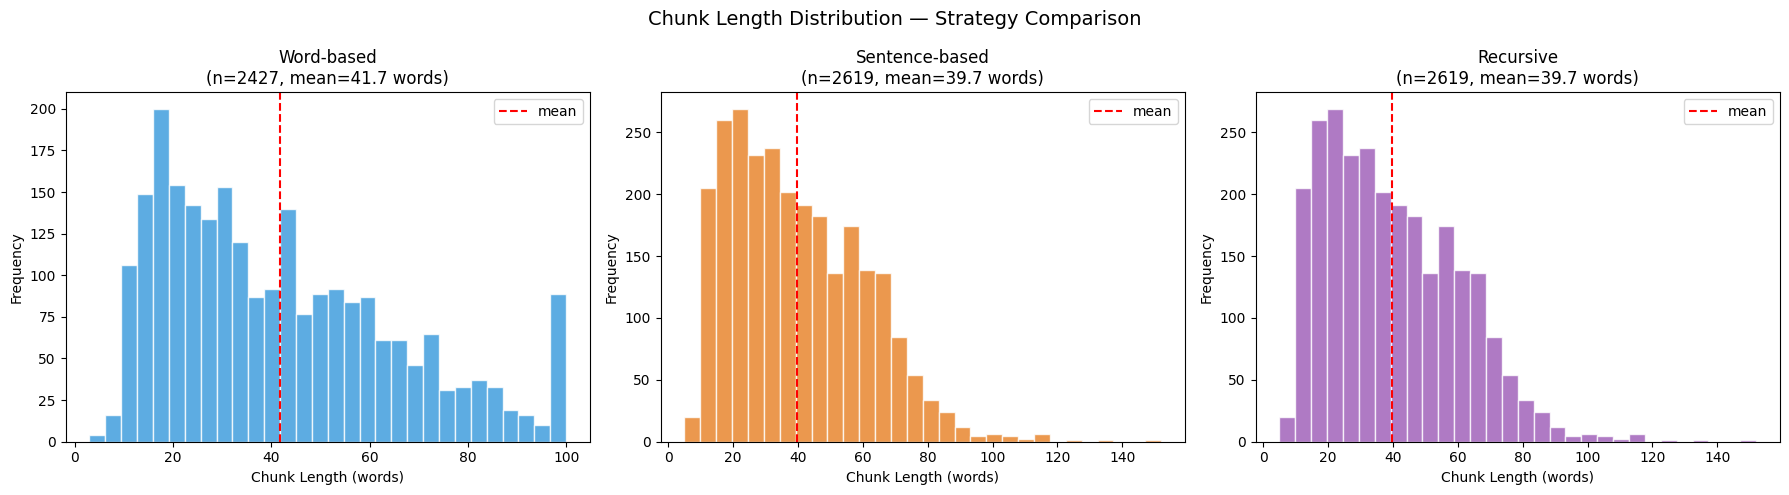


Stats Summary:
                 count  mean_len  std_len
Word-based      2427.0      41.7     23.7
Sentence-based  2619.0      39.7     20.6
Recursive       2619.0      39.7     20.6


In [95]:
# Visualise chunk length distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
strategies = [
    (chunks_word, 'Word-based', '#3498db'),
    (chunks_sentence, 'Sentence-based', '#e67e22'),
    (chunks_recursive, 'Recursive', '#9b59b6'),
]

chunk_stats = {}
for ax, (chunks, name, color) in zip(axes, strategies):
    lengths = [len(c.split()) for c in chunks]
    chunk_stats[name] = {
        'count': len(chunks),
        'mean_len': round(np.mean(lengths), 1),
        'std_len': round(np.std(lengths), 1),
    }
    ax.hist(lengths, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{name}\n(n={len(chunks)}, mean={chunk_stats[name]["mean_len"]} words)')
    ax.set_xlabel('Chunk Length (words)')
    ax.set_ylabel('Frequency')
    ax.axvline(np.mean(lengths), color='red', linestyle='--', label='mean')
    ax.legend()

plt.suptitle('Chunk Length Distribution — Strategy Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('chunking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nStats Summary:")
print(pd.DataFrame(chunk_stats).T)

In [96]:
# =========================
# Embedding Model Comparison
# =========================

print("Multiple Embedding Model Comparison")

sample_size = min(EMBEDDING_SAMPLE_SIZE, len(final_emb_chunks))
sample_chunks = final_emb_chunks[:sample_size]

print(f"Sample chunks used: {len(sample_chunks):,}")

model_results = {}

for model_name, model_path in EMBEDDING_MODELS.items():
    print("\n" + "=" * 70)
    print(f"Loading model: {model_name}")
    print(f"Model path   : {model_path}")

    try:
        start_load = time.time()

        m = SentenceTransformer(
            model_path,
            trust_remote_code=True
        )

        load_time = time.time() - start_load

        start_encode = time.time()

        embs = m.encode(
            sample_chunks,
            batch_size=EMBEDDING_BATCH_SIZE,
            show_progress_bar=True,
            normalize_embeddings=True,
            convert_to_numpy=True
        )

        encode_time = time.time() - start_encode

        embs = np.asarray(embs, dtype="float32")

        model_results[model_name] = {
            "model": m,
            "embeddings": embs,
            "dim": embs.shape[1],
            "load_time_sec": round(load_time, 2),
            "encode_time_sec": round(encode_time, 2),
            "total_time_sec": round(load_time + encode_time, 2),
            "chunks_per_sec": round(len(sample_chunks) / encode_time, 2) if encode_time > 0 else None,
            "path": model_path,
        }

        print(f"Status          : Success")
        print(f"Dimensions      : {embs.shape[1]}")
        print(f"Load time       : {load_time:.2f}s")
        print(f"Encode time     : {encode_time:.2f}s")
        print(f"Chunks / second : {model_results[model_name]['chunks_per_sec']}")

    except Exception as e:
        model_results[model_name] = {
            "model": None,
            "embeddings": None,
            "dim": None,
            "load_time_sec": None,
            "encode_time_sec": None,
            "total_time_sec": None,
            "chunks_per_sec": None,
            "path": model_path,
            "error": str(e),
        }

        print(f"Status: Failed")
        print(f"Error : {e}")


summary_rows = []

for model_name, info in model_results.items():
    summary_rows.append([
        model_name,
        info["path"],
        info["dim"],
        info["load_time_sec"],
        info["encode_time_sec"],
        info["total_time_sec"],
        info["chunks_per_sec"],
        "Failed" if info.get("error") else "Success",
    ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=[
        "Model",
        "Path",
        "Dim",
        "Load Time (s)",
        "Encode Time (s)",
        "Total Time (s)",
        "Chunks/sec",
        "Status",
    ]
)

print("\nEmbedding Model Comparison Summary:")
print(tabulate(summary_df, headers="keys", tablefmt="grid", showindex=False))

Multiple Embedding Model Comparison
Sample chunks used: 1,000

Loading model: BGE-Small
Model path   : BAAI/bge-small-en-v1.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Status          : Success
Dimensions      : 384
Load time       : 2.80s
Encode time     : 1.24s
Chunks / second : 804.61

Loading model: MiniLM-L6
Model path   : sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Status          : Success
Dimensions      : 384
Load time       : 3.70s
Encode time     : 1.46s
Chunks / second : 686.22

Embedding Model Comparison Summary:
+-----------+----------------------------------------+-------+-----------------+-------------------+------------------+--------------+----------+
| Model     | Path                                   |   Dim |   Load Time (s) |   Encode Time (s) |   Total Time (s) |   Chunks/sec | Status   |
+===========+========================================+=======+=================+===================+==================+==============+==========+
| BGE-Small | BAAI/bge-small-en-v1.5                 |   384 |             2.8 |              1.24 |             4.05 |       804.61 | Success  |
+-----------+----------------------------------------+-------+-----------------+-------------------+------------------+--------------+----------+
| MiniLM-L6 | sentence-transformers/all-MiniLM-L6-v2 |   384 |             3.7 |              1.46 |            

Scoring models on test queries...
  BGE-Small: 0.7523
  MiniLM-L6: 0.5992

Top retrieval examples for: BGE-Small
+----------------------------------------+--------------+-------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| query                                  |   best_score |   avg_top_k_score | top_chunk                                                                                                                                                                                                    |
+========================================+==============+===================+==============================================================================================================================================================================================================+
| How to control pests in cotton

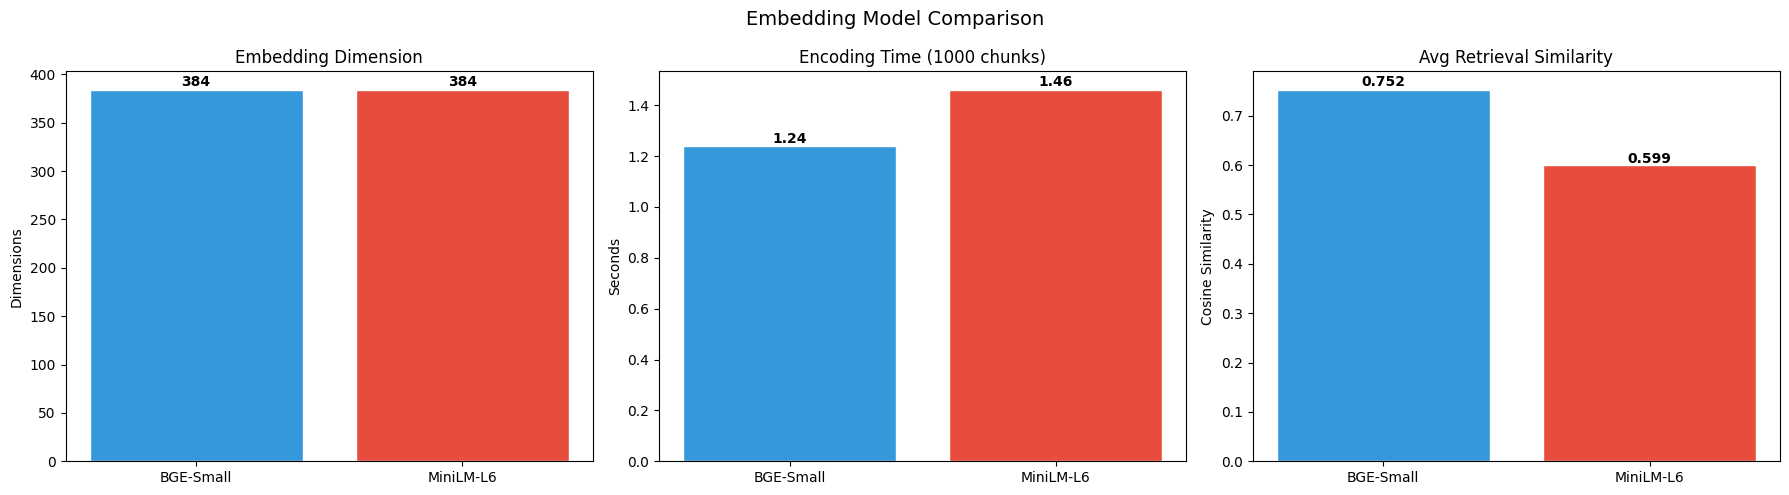


Best model by average similarity: BGE-Small
Score: 0.7523

Note: Average similarity is a quick signal, but final selection should also consider retrieved chunk relevance and speed.


In [97]:
# =========================
# Score and Visualise Model Comparison
# =========================

def evaluate_model_retrieval(model_info, queries, chunks, top_k=5):
    m = model_info["model"]
    embs = model_info["embeddings"]

    idx = faiss.IndexFlatIP(model_info["dim"])
    idx.add(embs)

    query_scores = []
    query_examples = []

    for query in queries:
        q_emb = m.encode(
            [query],
            normalize_embeddings=True,
            convert_to_numpy=True
        ).astype("float32")

        dists, ids = idx.search(q_emb, top_k)

        avg_score = float(np.mean(dists[0]))
        best_score = float(dists[0][0])

        query_scores.append(avg_score)

        top_id = int(ids[0][0])
        top_chunk = chunks[top_id] if top_id >= 0 else ""

        query_examples.append({
            "query": query,
            "best_score": round(best_score, 4),
            "avg_top_k_score": round(avg_score, 4),
            "top_chunk": top_chunk[:250],
        })

    return round(np.mean(query_scores), 4), query_examples


print("Scoring models on test queries...")

model_scores = {}
model_examples = {}

for name, info in model_results.items():
    if info["model"] is None:
        continue

    score, examples = evaluate_model_retrieval(
        model_info=info,
        queries=TEST_QUERIES,
        chunks=sample_chunks,
        top_k=5
    )

    model_scores[name] = score
    model_examples[name] = examples

    print(f"  {name}: {score}")


# Show top retrieved example for manual inspection
for name, examples in model_examples.items():
    print("\n" + "=" * 80)
    print(f"Top retrieval examples for: {name}")

    example_df = pd.DataFrame(examples)
    print(tabulate(example_df, headers="keys", tablefmt="grid", showindex=False))


names = list(model_scores.keys())

colors = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"][:len(names)]

dimensions = [model_results[n]["dim"] for n in names]
encode_times = [
    model_results[n].get("encode_time_sec", model_results[n].get("time_sec"))
    for n in names
]
similarities = [model_scores[n] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_data = [
    (dimensions, "Embedding Dimension", "Dimensions"),
    (encode_times, f"Encoding Time ({len(sample_chunks)} chunks)", "Seconds"),
    (similarities, "Avg Retrieval Similarity", "Cosine Similarity"),
]

for ax, (values, title, ylabel) in zip(axes, plot_data):
    ax.bar(names, values, color=colors, edgecolor="white")
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)

    for i, v in enumerate(values):
        ax.text(
            i,
            v * 1.01 if v else 0.01,
            str(round(v, 3)),
            ha="center",
            fontweight="bold"
        )

plt.suptitle("Embedding Model Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("reports/figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


best_model_name = max(model_scores, key=model_scores.get)
best_model_info = model_results[best_model_name]

print(f"\nBest model by average similarity: {best_model_name}")
print(f"Score: {model_scores[best_model_name]}")
print("\nNote: Average similarity is a quick signal, but final selection should also consider retrieved chunk relevance and speed.")

In [98]:
# =========================
# Generate Full Embeddings with Best Model
# =========================

import os

print(f"\nGenerating FULL embeddings using: {best_model_name}")
print(f"Chunks to embed: {len(final_emb_chunks):,}")

best_model = best_model_info["model"]

os.makedirs(os.path.dirname(EMBEDDINGS_SAVE_PATH), exist_ok=True)

full_embeddings = best_model.encode(
    final_emb_chunks,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)

full_embeddings = np.asarray(full_embeddings, dtype="float32")

print(f"Embedding shape: {full_embeddings.shape}")
print(f"Embedding dtype : {full_embeddings.dtype}")

np.save(EMBEDDINGS_SAVE_PATH, full_embeddings)

print(f"Saved embeddings to: {EMBEDDINGS_SAVE_PATH}")


Generating FULL embeddings using: BGE-Small
Chunks to embed: 2,619


Batches:   0%|          | 0/82 [00:00<?, ?it/s]

Embedding shape: (2619, 384)
Embedding dtype : float32
Saved embeddings to: models/agri_embeddings.npy


EMBEDDING QUALITY ANALYSIS (UMAP)
Running UMAP on 1,000 embeddings...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete.

Topic distribution:
other         429
fertilizer    148
pest          132
soil          121
disease       119
irrigation     51
Name: count, dtype: int64


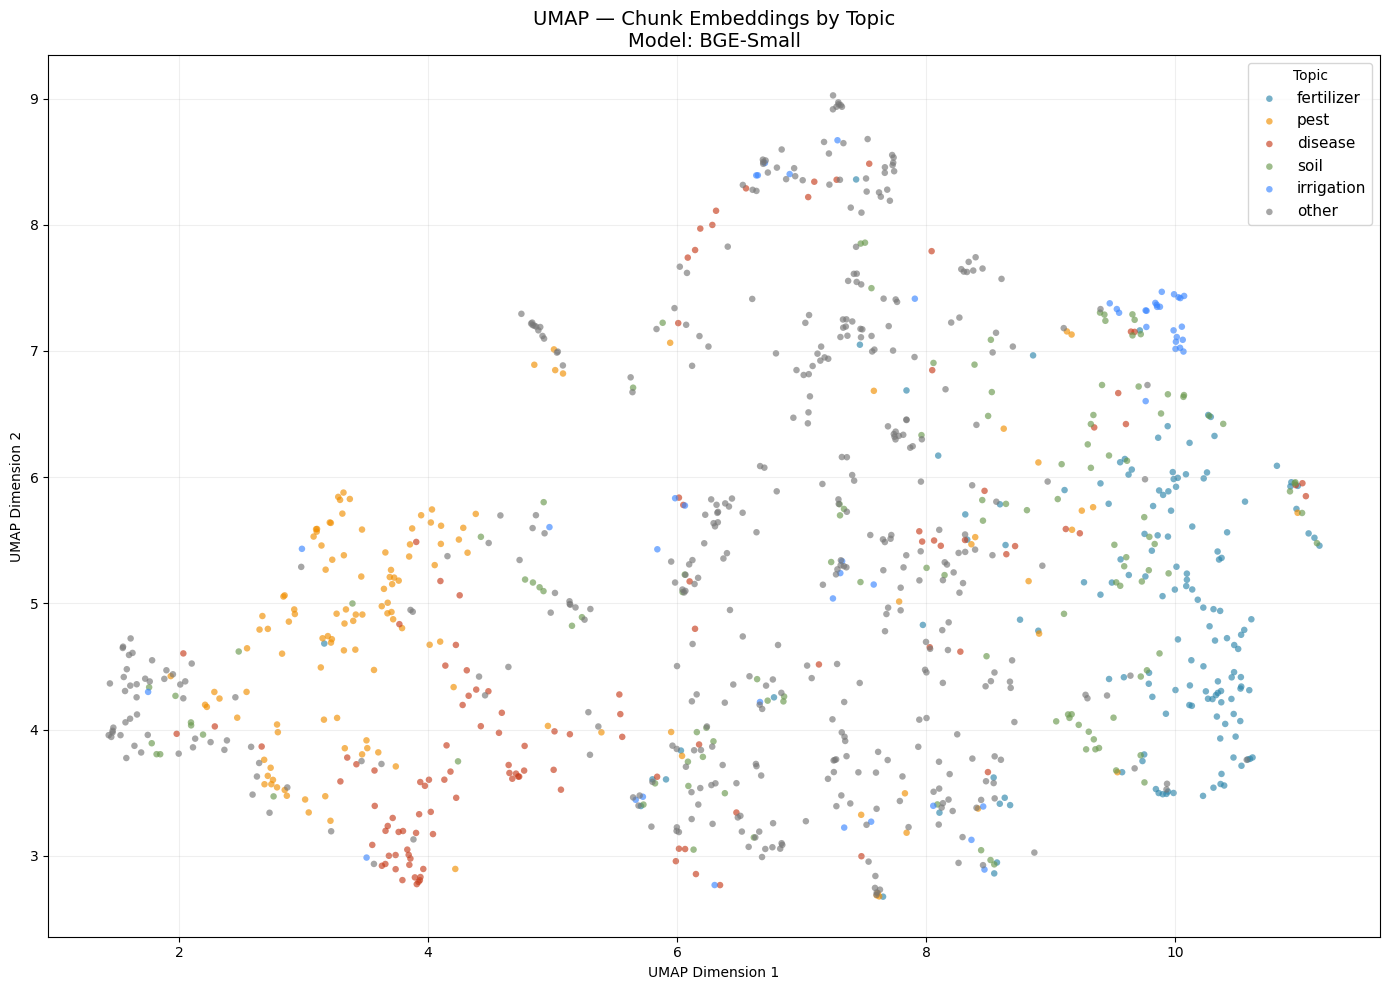


Intra-topic Cosine Similarity
(higher means chunks in that topic are closer together)
+------------+------------+------------------------------+
| topic      |   n_chunks |   avg_intra_topic_similarity |
+============+============+==============================+
| fertilizer |        148 |                       0.7318 |
+------------+------------+------------------------------+
| pest       |        132 |                       0.7381 |
+------------+------------+------------------------------+
| disease    |        119 |                       0.7322 |
+------------+------------+------------------------------+
| soil       |        121 |                       0.7042 |
+------------+------------+------------------------------+
| irrigation |         51 |                       0.7002 |
+------------+------------+------------------------------+

Saved figure to: reports/figures/umap_embeddings.png


In [99]:
# =========================
# UMAP Embedding Visualisation
# =========================

import os

print("=" * 60)
print("EMBEDDING QUALITY ANALYSIS (UMAP)")
print("=" * 60)

os.makedirs("reports/figures", exist_ok=True)

VIZ_SAMPLE = min(1000, len(final_emb_chunks))

viz_embs = full_embeddings[:VIZ_SAMPLE]
viz_chunks = final_emb_chunks[:VIZ_SAMPLE]

print(f"Running UMAP on {VIZ_SAMPLE:,} embeddings...")

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

umap_2d = reducer.fit_transform(viz_embs)

print("UMAP complete.")


def assign_topic(text):
    text_lower = text.lower()

    for topic, keywords in TOPIC_KEYWORDS.items():
        if any(keyword in text_lower for keyword in keywords):
            return topic

    return "other"


labels = [assign_topic(chunk) for chunk in viz_chunks]

topic_counts = pd.Series(labels).value_counts()

print("\nTopic distribution:")
print(topic_counts)


fig, ax = plt.subplots(figsize=(14, 10))

for topic, color in TOPIC_COLORS.items():
    topic_lower = topic.lower()
    mask = np.array([label == topic_lower for label in labels])

    if mask.any():
        ax.scatter(
            umap_2d[mask, 0],
            umap_2d[mask, 1],
            c=color,
            label=topic,
            alpha=0.65,
            s=22,
            edgecolors="none"
        )

ax.set_title(
    f"UMAP — Chunk Embeddings by Topic\nModel: {best_model_name}",
    fontsize=14
)
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")
ax.legend(title="Topic", fontsize=11)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    "reports/figures/umap_embeddings.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


print("\nIntra-topic Cosine Similarity")
print("(higher means chunks in that topic are closer together)")

similarity_rows = []

for topic in TOPIC_KEYWORDS:
    indices = [i for i, label in enumerate(labels) if label == topic]

    if len(indices) < 2:
        continue

    sims = cosine_similarity(viz_embs[indices])
    np.fill_diagonal(sims, 0)

    avg_sim = sims.sum() / (len(indices) * (len(indices) - 1))

    similarity_rows.append({
        "topic": topic,
        "n_chunks": len(indices),
        "avg_intra_topic_similarity": round(avg_sim, 4)
    })

similarity_df = pd.DataFrame(similarity_rows)

print(tabulate(similarity_df, headers="keys", tablefmt="grid", showindex=False))

print("\nSaved figure to: reports/figures/umap_embeddings.png")

In [100]:

## Step 9A: Build Baseline FAISS Index
dim = full_embeddings.shape[1]

faiss_index = faiss.IndexFlatIP(dim)
faiss_index.add(full_embeddings)

print("FAISS index created")
print("Total vectors:", faiss_index.ntotal)
print("Vector dimension:", dim)

FAISS index created
Total vectors: 2619
Vector dimension: 384


FAISS INDEX TYPE COMPARISON
Total vectors: 2,619
Vector dimension: 384

Benchmark Results:
+------------------+-----------+-------------------+--------------------------+
|                  |   Vectors |   Build Time (ms) |   Search Time/query (ms) |
+==================+===========+===================+==========================+
| FlatIP (Exact)   |      2619 |              1.31 |                   0.6071 |
+------------------+-----------+-------------------+--------------------------+
| IVFFlat (Approx) |      2619 |            107.87 |                   0.1081 |
+------------------+-----------+-------------------+--------------------------+
| HNSW (Graph)     |      2619 |            294    |                   0.1487 |
+------------------+-----------+-------------------+--------------------------+

Accuracy vs FlatIP ground truth:
  FlatIP (Exact)           : 100.0% match with exact search
  IVFFlat (Approx)         : 92.0% match with exact search
  HNSW (Graph)             : 100.0% 

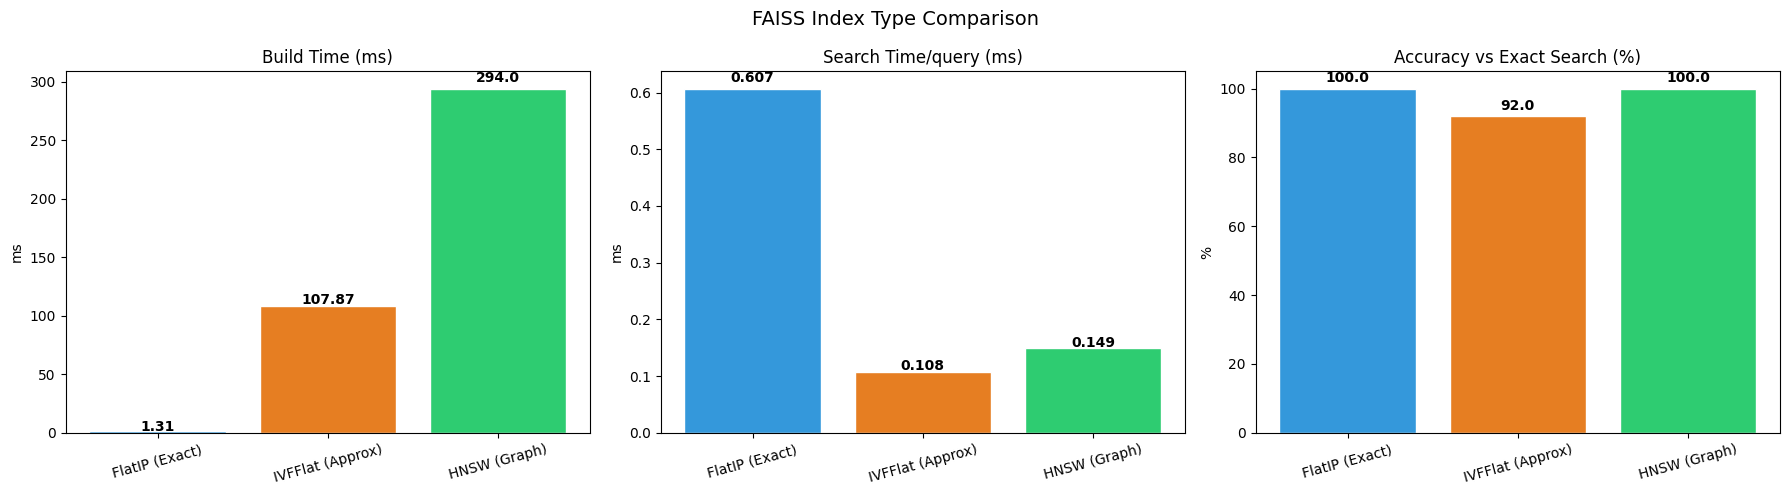


Selected FAISS index: FlatIP (Exact)
Saved figure to: reports/figures/faiss_comparison.png


In [101]:
## Step 9B: Compare FAISS Index Types

print("=" * 60)
print("FAISS INDEX TYPE COMPARISON")
print("=" * 60)

os.makedirs("reports/figures", exist_ok=True)

dim = full_embeddings.shape[1]
n = full_embeddings.shape[0]

print(f"Total vectors: {n:,}")
print(f"Vector dimension: {dim}")

TEST_QUERIES_EMB = best_model.encode(
    TEST_QUERIES,
    normalize_embeddings=True,
    convert_to_numpy=True
).astype("float32")


def build_and_benchmark(index_obj, embeddings, queries_emb, top_k=5):
    t0 = time.time()

    if hasattr(index_obj, "train") and not index_obj.is_trained:
        index_obj.train(embeddings)

    index_obj.add(embeddings)

    build_time = (time.time() - t0) * 1000

    t0 = time.time()

    for q in queries_emb:
        index_obj.search(q.reshape(1, -1), top_k)

    search_time = (time.time() - t0) / len(queries_emb) * 1000

    return {
        "index": index_obj,
        "build_ms": round(build_time, 2),
        "search_ms": round(search_time, 4),
        "ntotal": index_obj.ntotal,
    }


INDEX_CONFIGS = {}

# 1. FlatIP exact search
INDEX_CONFIGS["FlatIP (Exact)"] = build_and_benchmark(
    faiss.IndexFlatIP(dim),
    full_embeddings,
    TEST_QUERIES_EMB,
    top_k=5
)

# 2. IVFFlat approximate search
# nlist controls number of clusters. For small datasets, keep it modest.
nlist = max(2, min(50, n // 10))

quantizer = faiss.IndexFlatIP(dim)

ivf_index = faiss.IndexIVFFlat(
    quantizer,
    dim,
    nlist,
    faiss.METRIC_INNER_PRODUCT
)

# nprobe controls how many clusters are searched.
# Higher nprobe = better accuracy, slower search.
ivf_index.nprobe = min(10, nlist)

INDEX_CONFIGS["IVFFlat (Approx)"] = build_and_benchmark(
    ivf_index,
    full_embeddings,
    TEST_QUERIES_EMB,
    top_k=5
)

# 3. HNSW graph search
hnsw_index = faiss.IndexHNSWFlat(dim, 32)
hnsw_index.hnsw.efSearch = 64

INDEX_CONFIGS["HNSW (Graph)"] = build_and_benchmark(
    hnsw_index,
    full_embeddings,
    TEST_QUERIES_EMB,
    top_k=5
)


benchmark_df = pd.DataFrame({
    name: {
        "Vectors": config["ntotal"],
        "Build Time (ms)": config["build_ms"],
        "Search Time/query (ms)": config["search_ms"],
    }
    for name, config in INDEX_CONFIGS.items()
}).T

print("\nBenchmark Results:")
print(tabulate(benchmark_df, headers="keys", tablefmt="grid"))


def get_top_k_ids(index_obj, query_emb, top_k=5):
    _, ids = index_obj.search(query_emb.reshape(1, -1), top_k)
    return set(int(i) for i in ids[0] if i >= 0)


print("\nAccuracy vs FlatIP ground truth:")

accuracy_results = {}
flat_index = INDEX_CONFIGS["FlatIP (Exact)"]["index"]

for name, config in INDEX_CONFIGS.items():
    overlaps = []

    for q in TEST_QUERIES_EMB:
        exact_ids = get_top_k_ids(flat_index, q, top_k=5)
        test_ids = get_top_k_ids(config["index"], q, top_k=5)

        overlap = len(exact_ids & test_ids) / 5
        overlaps.append(overlap)

    accuracy_results[name] = round(float(np.mean(overlaps)), 4)

    print(
        f"  {name:25s}: "
        f"{accuracy_results[name] * 100:.1f}% match with exact search"
    )


faiss_names = list(INDEX_CONFIGS.keys())
faiss_colors = ["#3498db", "#e67e22", "#2ecc71"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_values = [
    [INDEX_CONFIGS[name]["build_ms"] for name in faiss_names],
    [INDEX_CONFIGS[name]["search_ms"] for name in faiss_names],
    [accuracy_results[name] * 100 for name in faiss_names],
]

plot_titles = [
    "Build Time (ms)",
    "Search Time/query (ms)",
    "Accuracy vs Exact Search (%)",
]

plot_ylabels = ["ms", "ms", "%"]

for ax, values, title, ylabel in zip(axes, plot_values, plot_titles, plot_ylabels):
    ax.bar(faiss_names, values, color=faiss_colors, edgecolor="white")
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=15)

    for i, v in enumerate(values):
        ax.text(
            i,
            v * 1.02 if v else 0.01,
            str(round(v, 3)),
            ha="center",
            fontweight="bold"
        )

plt.suptitle("FAISS Index Type Comparison", fontsize=14)
plt.tight_layout()
plt.savefig(
    "reports/figures/faiss_comparison.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# For this dataset size, exact search is fast and gives perfect retrieval.
BEST_INDEX_NAME = "FlatIP (Exact)" if n < 100_000 else "HNSW (Graph)"
BEST_INDEX = INDEX_CONFIGS[BEST_INDEX_NAME]["index"]

print(f"\nSelected FAISS index: {BEST_INDEX_NAME}")
print("Saved figure to: reports/figures/faiss_comparison.png")

In [102]:
# =========================
# Step 10: Build BM25 Index
# =========================

print("=" * 60)
print("BUILD BM25 INDEX")
print("=" * 60)

tokenized_bm25_chunks = [chunk.split() for chunk in final_bm25_chunks]

bm25_index = BM25Okapi(tokenized_bm25_chunks)

print("BM25 index created")
print(f"Total BM25 chunks: {len(tokenized_bm25_chunks):,}")
print(f"Vocabulary size  : {len(bm25_index.idf):,}")

print("\nExample BM25 tokens:")
print(tokenized_bm25_chunks[0][:30])

BUILD BM25 INDEX
BM25 index created
Total BM25 chunks: 2,619
Vocabulary size  : 5,675

Example BM25 tokens:
['crop', 'rotation', 'important', 'farming', 'helps', 'prevent', 'erosion', 'depletion', 'control', 'pests', 'diseases']


In [103]:
print('Loading Cross-Encoder reranker...')
cross_encoder = CrossEncoder(CROSS_ENCODER_BASE)
print(f'Cross-Encoder loaded: {CROSS_ENCODER_BASE}')

Loading Cross-Encoder reranker...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cross-Encoder loaded: cross-encoder/ms-marco-MiniLM-L-6-v2


EMBEDDING CLUSTER QUALITY ANALYSIS
Computing topic centroids and inter-cluster separation...
Topics with enough data: ['fertilizer', 'pest', 'disease', 'soil', 'irrigation']

Cluster Cohesion Summary:
+------------+------------+----------------------------+
| topic      |   n_chunks |   intra_cluster_similarity |
+============+============+============================+
| pest       |        132 |                     0.7381 |
+------------+------------+----------------------------+
| disease    |        119 |                     0.7322 |
+------------+------------+----------------------------+
| fertilizer |        148 |                     0.7318 |
+------------+------------+----------------------------+
| soil       |        121 |                     0.7042 |
+------------+------------+----------------------------+
| irrigation |         51 |                     0.7002 |
+------------+------------+----------------------------+


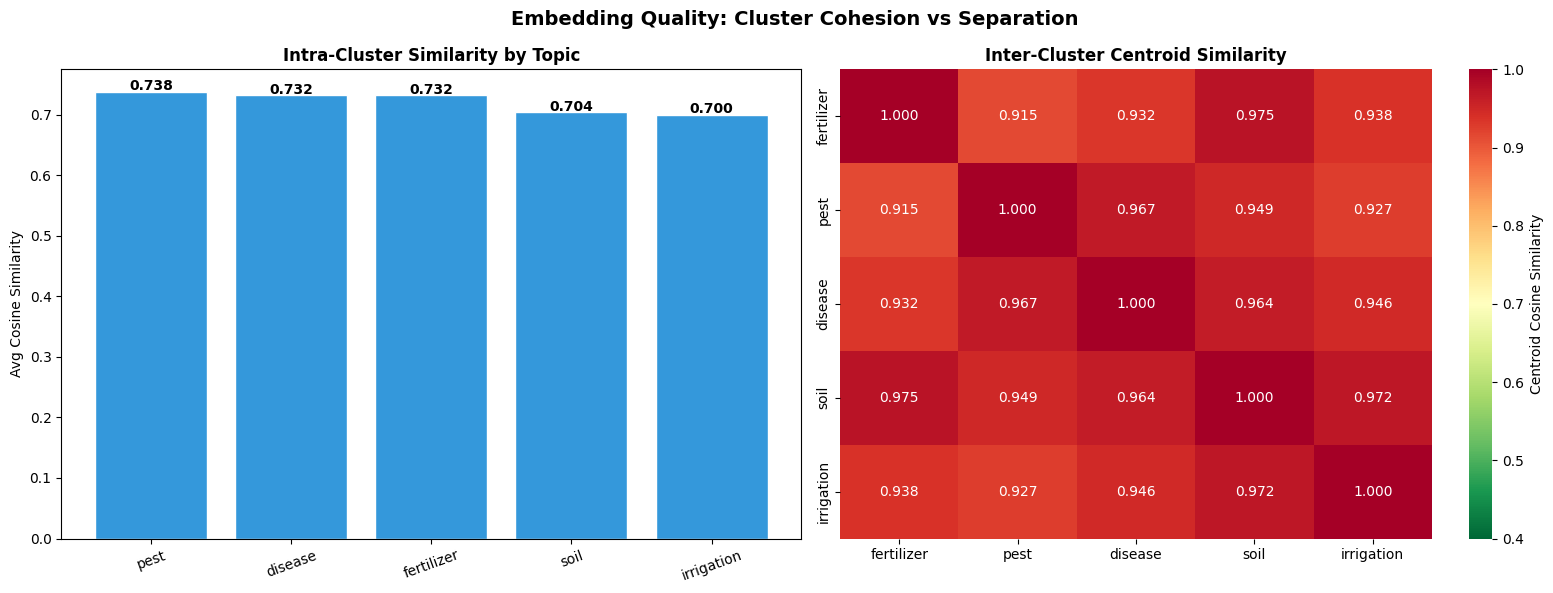


Overall Embedding Cluster Metrics:
Mean intra-cluster similarity : 0.7213  (want HIGH)
Mean inter-cluster similarity : 0.9486  (want LOW)
Separation ratio intra/inter : 0.76x  (want > 1.0)

Saved figure to: reports/figures/embedding_cluster_analysis.png


In [104]:
# =========================
# Inter-Cluster and Embedding Quality Analysis
# =========================

import os

print("=" * 60)
print("EMBEDDING CLUSTER QUALITY ANALYSIS")
print("=" * 60)

os.makedirs("reports/figures", exist_ok=True)

print("Computing topic centroids and inter-cluster separation...")

topics_with_data = []

for topic in TOPIC_KEYWORDS:
    count = sum(1 for label in labels if label == topic)

    if count >= 2:
        topics_with_data.append(topic)

print(f"Topics with enough data: {topics_with_data}")

if len(topics_with_data) < 2:
    print("Not enough labeled topics for cluster separation analysis.")

else:
    centroids = {}
    intra_sim = {}
    topic_counts = {}

    for topic in topics_with_data:
        idxs = [i for i, label in enumerate(labels) if label == topic]
        topic_counts[topic] = len(idxs)

        topic_embs = viz_embs[idxs]

        # Topic centroid = average embedding for that topic
        centroids[topic] = topic_embs.mean(axis=0)

        # Limit pairwise similarity calculation for speed
        sample_idxs = idxs[:min(200, len(idxs))]
        sample_embs = viz_embs[sample_idxs]

        sims = cosine_similarity(sample_embs)

        # Remove self-similarity from the diagonal
        np.fill_diagonal(sims, 0)

        n_s = len(sample_idxs)

        if n_s > 1:
            intra_score = sims.sum() / (n_s * (n_s - 1))
        else:
            intra_score = 0.0

        intra_sim[topic] = round(float(intra_score), 4)


    n_topics = len(topics_with_data)

    inter_matrix = np.zeros((n_topics, n_topics))

    for i, t1 in enumerate(topics_with_data):
        for j, t2 in enumerate(topics_with_data):
            c1 = centroids[t1].reshape(1, -1)
            c2 = centroids[t2].reshape(1, -1)

            inter_matrix[i, j] = float(cosine_similarity(c1, c2)[0][0])


    inter_df = pd.DataFrame(
        inter_matrix,
        index=topics_with_data,
        columns=topics_with_data
    )


    # Summary table
    cluster_summary = pd.DataFrame([
        {
            "topic": topic,
            "n_chunks": topic_counts[topic],
            "intra_cluster_similarity": intra_sim[topic],
        }
        for topic in topics_with_data
    ]).sort_values(
        by="intra_cluster_similarity",
        ascending=False
    )

    print("\nCluster Cohesion Summary:")
    print(tabulate(cluster_summary, headers="keys", tablefmt="grid", showindex=False))


    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sorted_topics = cluster_summary["topic"].tolist()
    sorted_scores = [intra_sim[topic] for topic in sorted_topics]

    axes[0].bar(
        sorted_topics,
        sorted_scores,
        color="#3498db",
        edgecolor="white"
    )

    axes[0].set_title(
        "Intra-Cluster Similarity by Topic",
        fontsize=12,
        fontweight="bold"
    )
    axes[0].set_ylabel("Avg Cosine Similarity")
    axes[0].tick_params(axis="x", rotation=20)

    for i, score in enumerate(sorted_scores):
        axes[0].text(
            i,
            score + 0.002,
            f"{score:.3f}",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )


    sns.heatmap(
        inter_df,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn_r",
        vmin=0.4,
        vmax=1.0,
        ax=axes[1],
        cbar_kws={"label": "Centroid Cosine Similarity"}
    )

    axes[1].set_title(
        "Inter-Cluster Centroid Similarity",
        fontsize=12,
        fontweight="bold"
    )


    plt.suptitle(
        "Embedding Quality: Cluster Cohesion vs Separation",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        "reports/figures/embedding_cluster_analysis.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()


    # Overall separation metrics
    mask = ~np.eye(n_topics, dtype=bool)

    mean_intra = float(np.mean(list(intra_sim.values())))
    mean_inter = float(inter_matrix[mask].mean())

    if mean_inter > 0:
        separation_ratio = mean_intra / mean_inter
    else:
        separation_ratio = np.nan

    print("\nOverall Embedding Cluster Metrics:")
    print(f"Mean intra-cluster similarity : {mean_intra:.4f}  (want HIGH)")
    print(f"Mean inter-cluster similarity : {mean_inter:.4f}  (want LOW)")
    print(f"Separation ratio intra/inter : {separation_ratio:.2f}x  (want > 1.0)")

    print("\nSaved figure to: reports/figures/embedding_cluster_analysis.png")

HARD NEGATIVE ANALYSIS: TOPIC BLEED-IN RATE

Summary:
+------------------+---------------------------------------------------------+------------+-------------+-------------+
| Expected Topic   | Query                                                   | On-Topic   | Off-Topic   |   Precision |
+==================+=========================================================+============+=============+=============+
| fertilizer       | Which fertilizer should be used for better crop growth? | 10/10      | 0/10        |         1   |
+------------------+---------------------------------------------------------+------------+-------------+-------------+
| pest             | How can I control insect pests on my crop?              | 10/10      | 0/10        |         1   |
+------------------+---------------------------------------------------------+------------+-------------+-------------+
| disease          | How to treat fungal disease in plants?                  | 9/10       | 1/10        | 

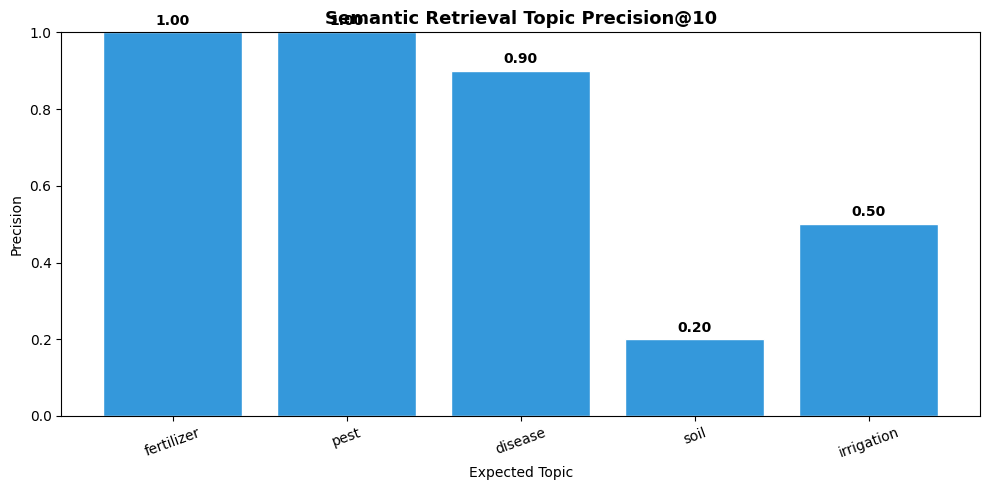


Saved figure to: reports/figures/hard_negative_topic_bleed_in.png


In [105]:
# =========================
# Hard Negative Analysis: Topic Bleed-In Rate
# =========================

print("=" * 70)
print("HARD NEGATIVE ANALYSIS: TOPIC BLEED-IN RATE")
print("=" * 70)

def retrieve_semantic_raw(query, model, index, chunks, top_k=10):
    query_embedding = model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype("float32")

    scores, ids = index.search(query_embedding, top_k)

    results = []

    for score, chunk_id in zip(scores[0], ids[0]):
        if chunk_id < 0:
            continue

        results.append({
            "chunk_id": int(chunk_id),
            "chunk": chunks[int(chunk_id)],
            "score": float(score),
        })

    return results


rows_hn = []
detailed_rows = []

TOP_K_HARD_NEGATIVE = 10

for expected_topic, query in TOPIC_QUERIES.items():
    results = retrieve_semantic_raw(
        query=query,
        model=best_model,
        index=BEST_INDEX,
        chunks=final_emb_chunks,
        top_k=TOP_K_HARD_NEGATIVE
    )

    result_labels = [assign_topic(result["chunk"]) for result in results]

    on_topic = sum(1 for label in result_labels if label == expected_topic)
    off_topic = len(results) - on_topic

    precision = on_topic / len(results) if results else 0.0

    rows_hn.append({
        "Expected Topic": expected_topic,
        "Query": query,
        "On-Topic": f"{on_topic}/{len(results)}",
        "Off-Topic": f"{off_topic}/{len(results)}",
        "Precision": round(precision, 3),
    })

    for rank, result in enumerate(results, start=1):
        detailed_rows.append({
            "expected_topic": expected_topic,
            "rank": rank,
            "retrieved_topic": result_labels[rank - 1],
            "score": round(result["score"], 4),
            "chunk_preview": result["chunk"][:160],
        })


hard_negative_df = pd.DataFrame(rows_hn)

print("\nSummary:")
print(tabulate(
    hard_negative_df,
    headers="keys",
    tablefmt="grid",
    showindex=False
))


print("\nDetailed retrieved-topic breakdown:")
detailed_hn_df = pd.DataFrame(detailed_rows)

print(tabulate(
    detailed_hn_df.head(30),
    headers="keys",
    tablefmt="grid",
    showindex=False
))


avg_precision = hard_negative_df["Precision"].mean()

print("\nOverall Topic Precision:")
print(f"Average topic precision@{TOP_K_HARD_NEGATIVE}: {avg_precision:.3f}")


# Optional visualization
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    hard_negative_df["Expected Topic"],
    hard_negative_df["Precision"],
    color="#3498db",
    edgecolor="white"
)

ax.set_ylim(0, 1)
ax.set_title(
    f"Semantic Retrieval Topic Precision@{TOP_K_HARD_NEGATIVE}",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Expected Topic")
ax.set_ylabel("Precision")
ax.tick_params(axis="x", rotation=20)

for i, value in enumerate(hard_negative_df["Precision"]):
    ax.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    "reports/figures/hard_negative_topic_bleed_in.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print("\nSaved figure to: reports/figures/hard_negative_topic_bleed_in.png")

In [106]:
# =========================
# Build Ground-Truth Retrieval Test Set
# =========================

print("=" * 60)
print("BUILD GROUND-TRUTH RETRIEVAL TEST SET")
print("=" * 60)

row_to_chunks = defaultdict(set)

for meta in final_meta:
    row_to_chunks[meta["source_row"]].add(meta["chunk_id"])


sampled_rows = df.sample(
    n=min(EVAL_TEST_SIZE, len(df)),
    random_state=42
)


eval_queries = []

for row_idx, row in sampled_rows.iterrows():
    relevant_ids = row_to_chunks.get(row_idx, set())

    if not relevant_ids:
        continue

    eval_queries.append({
        "query": row["question"],
        "relevant_ids": relevant_ids,
        "source_row": row_idx,
        "reference_answer": row["answers"],
    })


avg_relevant = np.mean(
    [len(item["relevant_ids"]) for item in eval_queries]
) if eval_queries else 0


print(f"Evaluation test set: {len(eval_queries)} queries")
print(f"Average relevant chunks/query: {avg_relevant:.2f}")

print("\nExample evaluation query:")
print(eval_queries[0]["query"])

print("\nRelevant chunk IDs:")
print(eval_queries[0]["relevant_ids"])

BUILD GROUND-TRUTH RETRIEVAL TEST SET
Evaluation test set: 6 queries
Average relevant chunks/query: 1.17

Example evaluation query:
What are the symptoms of Panama disease in banana plants?

Relevant chunk IDs:
{2484}


In [107]:
# =========================
# Build Ground-Truth Test Set
# =========================

print("=" * 60)
print("BUILD GROUND-TRUTH TEST SET")
print("=" * 60)

row_to_chunks = defaultdict(set)

for meta in final_meta:
    row_to_chunks[meta["source_row"]].add(meta["chunk_id"])


sampled_rows = df.sample(
    n=min(EVAL_TEST_SIZE, len(df)),
    random_state=42
)


eval_queries = []

for row_idx, row in sampled_rows.iterrows():
    relevant_ids = row_to_chunks.get(row_idx, set())

    if not relevant_ids:
        continue

    eval_queries.append({
        "query": row["question"],
        "relevant_ids": relevant_ids,
        "source_row": row_idx,
        "reference_answer": row["answers"],
    })


avg_relevant = (
    np.mean([len(q["relevant_ids"]) for q in eval_queries])
    if eval_queries
    else 0
)

print(f"Evaluation test set: {len(eval_queries)} queries")
print(f"Avg relevant chunks/query: {avg_relevant:.2f}")

if eval_queries:
    print("\nExample query:")
    print(eval_queries[0]["query"])

    print("\nRelevant chunk IDs:")
    print(eval_queries[0]["relevant_ids"])

    print("\nReference answer preview:")
    print(eval_queries[0]["reference_answer"][:300])

BUILD GROUND-TRUTH TEST SET
Evaluation test set: 6 queries
Avg relevant chunks/query: 1.17

Example query:
What are the symptoms of Panama disease in banana plants?

Relevant chunk IDs:
{2484}

Reference answer preview:
Symptoms of Panama disease in banana plants include yellowing of the lowermost leaves starting from the margin to the midrib, longitudinal splitting of the pseudostem, and discoloration of vascular vessels as red or brown streaks. Eventually, the leaves break near the base and hang down around the p


In [108]:
# =========================
# Retrieval Metric Functions
# =========================

def recall_at_k(retrieved, relevant, k):
    """
    Recall@K:
    Out of all relevant chunks, how many appeared in the top K?
    """
    if not relevant:
        return 0.0

    retrieved_at_k = set(retrieved[:k])
    relevant_set = set(relevant)

    return len(retrieved_at_k & relevant_set) / len(relevant_set)


def precision_at_k(retrieved, relevant, k):
    """
    Precision@K:
    Out of the top K retrieved chunks, how many were relevant?
    """
    if k == 0:
        return 0.0

    retrieved_at_k = retrieved[:k]
    relevant_set = set(relevant)

    return sum(1 for chunk_id in retrieved_at_k if chunk_id in relevant_set) / k


def mean_reciprocal_rank(retrieved, relevant):
    """
    MRR:
    Measures how high the first relevant chunk appears.
    Rank 1 gives 1.0, rank 2 gives 0.5, rank 3 gives 0.333, etc.
    """
    relevant_set = set(relevant)

    for rank, chunk_id in enumerate(retrieved, start=1):
        if chunk_id in relevant_set:
            return 1.0 / rank

    return 0.0


def ndcg_at_k(retrieved, relevant, k):
    """
    NDCG@K:
    Rewards relevant chunks appearing higher in the ranking.
    """
    relevant_set = set(relevant)

    dcg = 0.0

    for rank, chunk_id in enumerate(retrieved[:k]):
        if chunk_id in relevant_set:
            dcg += 1.0 / math.log2(rank + 2)

    ideal_relevant_count = min(len(relevant_set), k)

    idcg = sum(
        1.0 / math.log2(rank + 2)
        for rank in range(ideal_relevant_count)
    )

    return dcg / idcg if idcg > 0 else 0.0


print("Metrics defined:")
print("  recall_at_k")
print("  precision_at_k")
print("  mean_reciprocal_rank")
print("  ndcg_at_k")

Metrics defined:
  recall_at_k
  precision_at_k
  mean_reciprocal_rank
  ndcg_at_k


In [109]:
# =========================
# Instantiate Pipeline Variants
# =========================

print("=" * 60)
print("BUILD PIPELINE VARIANTS")
print("=" * 60)


def expand_query(query):
    query_lower = query.lower()
    additions = []

    for phrase, expansion in QUERY_EXPANSIONS.items():
        if phrase in query_lower:
            additions.append(expansion)

    if additions:
        return query + " " + " ".join(additions)

    return query


common_args = dict(
    embedding_model=best_model,
    faiss_index=BEST_INDEX,
    bm25_index=bm25_index,
    chunks=final_emb_chunks,
    bm25_chunks=final_bm25_chunks,
    metadata=final_meta,
    cross_encoder=cross_encoder,
    retrieval_pool_k=TOP_K_SEMANTIC,
    final_top_k=FINAL_TOP_K,
    rrf_k=RRF_K,
    query_expander=expand_query,
)


pipeline = AgriRAGPipeline(
    **common_args,
    use_reranker=True
)


VARIANTS = {
    "A: Semantic Only": SemanticOnlyPipeline(
        **common_args,
        use_reranker=False
    ),

    "B: RRF only": AgriRAGPipeline(
        **common_args,
        use_reranker=False
    ),

    "C: Hybrid + CrossEnc": HybridCEPipeline(
        **common_args,
        semantic_weight=0.6,
        bm25_weight=0.4,
        use_reranker=True
    ),

    "D: RRF + CrossEnc": pipeline,
}


print("Pipeline ready: all variants created")
print(f"Stage 1: Query expansion enabled")
print(f"Stage 2: Semantic FAISS retrieval top-{TOP_K_SEMANTIC}")
print(f"Stage 3: BM25 keyword retrieval top-{TOP_K_BM25}")
print(f"Stage 4: Fusion / blending over top-{pipeline.retrieval_pool_k} candidates")
print(f"Stage 5: Cross-encoder reranking final top-{pipeline.final_top_k}")

BUILD PIPELINE VARIANTS
Pipeline ready: all variants created
Stage 1: Query expansion enabled
Stage 2: Semantic FAISS retrieval top-20
Stage 3: BM25 keyword retrieval top-20
Stage 4: Fusion / blending over top-20 candidates
Stage 5: Cross-encoder reranking final top-5


In [110]:
# =========================
# Evaluate All Pipeline Variants
# =========================

print("=" * 60)
print("EVALUATE PIPELINE VARIANTS")
print("=" * 60)

if not eval_queries:
    raise ValueError("eval_queries is empty. Build the ground-truth test set first.")

eval_results = {}

for vname, p in VARIANTS.items():
    print(f"\nEvaluating: {vname}")

    if hasattr(p, "cache"):
        p.cache = {}

    per_k = {
        k: {
            "recall": [],
            "precision": [],
            "mrr": [],
            "ndcg": [],
            "latency_ms": [],
        }
        for k in K_VALUES
    }

    for tq in tqdm(eval_queries, desc=f"  {vname}", leave=False):
        t0 = time.perf_counter()

        results = p.query(
            tq["query"],
            use_cache=False
        )

        latency_ms = (time.perf_counter() - t0) * 1000

        retrieved_ids = [result["chunk_id"] for result in results]
        relevant_ids = tq["relevant_ids"]

        mrr_value = mean_reciprocal_rank(retrieved_ids, relevant_ids)

        for k in K_VALUES:
            per_k[k]["recall"].append(
                recall_at_k(retrieved_ids, relevant_ids, k)
            )

            per_k[k]["precision"].append(
                precision_at_k(retrieved_ids, relevant_ids, k)
            )

            per_k[k]["mrr"].append(mrr_value)

            per_k[k]["ndcg"].append(
                ndcg_at_k(retrieved_ids, relevant_ids, k)
            )

            per_k[k]["latency_ms"].append(latency_ms)

    eval_results[vname] = {
        k: {
            metric: round(float(np.mean(values)), 4)
            for metric, values in metrics.items()
        }
        for k, metrics in per_k.items()
    }

    eval_results[vname]["n_queries"] = len(eval_queries)

    display_k = 5 if 5 in K_VALUES else max(K_VALUES)

    print(
        f"Done. "
        f"Recall@{display_k}: {eval_results[vname][display_k]['recall']:.4f} | "
        f"MRR: {eval_results[vname][display_k]['mrr']:.4f} | "
        f"NDCG@{display_k}: {eval_results[vname][display_k]['ndcg']:.4f} | "
        f"Avg latency: {eval_results[vname][display_k]['latency_ms']:.1f} ms"
    )


print("\nEvaluation complete.")
print(f"Variants evaluated: {list(VARIANTS.keys())}")
print(f"Evaluation queries: {len(eval_queries)}")

EVALUATE PIPELINE VARIANTS

Evaluating: A: Semantic Only


Done. Recall@5: 0.9167 | MRR: 0.8333 | NDCG@5: 0.8363 | Avg latency: 62.5 ms

Evaluating: B: RRF only


Done. Recall@5: 0.9167 | MRR: 0.8333 | NDCG@5: 0.8363 | Avg latency: 81.3 ms

Evaluating: C: Hybrid + CrossEnc


Done. Recall@5: 0.9167 | MRR: 0.8333 | NDCG@5: 0.8363 | Avg latency: 177.7 ms

Evaluating: D: RRF + CrossEnc


Done. Recall@5: 0.9167 | MRR: 0.8333 | NDCG@5: 0.8363 | Avg latency: 121.4 ms

Evaluation complete.
Variants evaluated: ['A: Semantic Only', 'B: RRF only', 'C: Hybrid + CrossEnc', 'D: RRF + CrossEnc']
Evaluation queries: 6


In [111]:
# =========================
# Print Evaluation Result Tables
# =========================

print("=" * 72)
print("EVALUATION RESULTS")
print("=" * 72)

all_eval_rows = []

for k in K_VALUES:
    print(f"\n-- K = {k} --")

    table_rows = []

    for vname in VARIANTS:
        scores = eval_results[vname][k]

        row = {
            "Variant": vname,
            "K": k,
            f"Recall@{k}": scores["recall"],
            f"Precision@{k}": scores["precision"],
            "MRR": scores["mrr"],
            f"NDCG@{k}": scores["ndcg"],
            "Latency (ms)": scores["latency_ms"],
        }

        all_eval_rows.append(row)

        table_rows.append([
            vname,
            f"{scores['recall']:.4f}",
            f"{scores['precision']:.4f}",
            f"{scores['mrr']:.4f}",
            f"{scores['ndcg']:.4f}",
            f"{scores['latency_ms']:.1f} ms",
        ])

    print(tabulate(
        table_rows,
        headers=[
            "Variant",
            f"Recall@{k}",
            f"Precision@{k}",
            "MRR",
            f"NDCG@{k}",
            "Latency",
        ],
        tablefmt="rounded_outline"
    ))


# Save results
eval_results_df = pd.DataFrame(all_eval_rows)

os.makedirs("reports", exist_ok=True)

eval_results_df.to_csv(
    "reports/retrieval_evaluation_results.csv",
    index=False
)

print("\nSaved evaluation results to: reports/retrieval_evaluation_results.csv")


# Best variant by NDCG at K=5 if available
best_k = 5 if 5 in K_VALUES else max(K_VALUES)

best_variant_name = max(
    VARIANTS.keys(),
    key=lambda name: eval_results[name][best_k]["ndcg"]
)

best_variant_scores = eval_results[best_variant_name][best_k]

print(f"\nBest variant by NDCG@{best_k}: {best_variant_name}")
print(f"Recall@{best_k} : {best_variant_scores['recall']:.4f}")
print(f"MRR       : {best_variant_scores['mrr']:.4f}")
print(f"NDCG@{best_k}   : {best_variant_scores['ndcg']:.4f}")
print(f"Latency   : {best_variant_scores['latency_ms']:.1f} ms")

EVALUATION RESULTS

-- K = 1 --
╭──────────────────────┬────────────┬───────────────┬────────┬──────────┬───────────╮
│ Variant              │   Recall@1 │   Precision@1 │    MRR │   NDCG@1 │ Latency   │
├──────────────────────┼────────────┼───────────────┼────────┼──────────┼───────────┤
│ A: Semantic Only     │     0.6667 │        0.6667 │ 0.8333 │   0.6667 │ 62.5 ms   │
│ B: RRF only          │     0.6667 │        0.6667 │ 0.8333 │   0.6667 │ 81.3 ms   │
│ C: Hybrid + CrossEnc │     0.6667 │        0.6667 │ 0.8333 │   0.6667 │ 177.7 ms  │
│ D: RRF + CrossEnc    │     0.6667 │        0.6667 │ 0.8333 │   0.6667 │ 121.4 ms  │
╰──────────────────────┴────────────┴───────────────┴────────┴──────────┴───────────╯

-- K = 3 --
╭──────────────────────┬────────────┬───────────────┬────────┬──────────┬───────────╮
│ Variant              │   Recall@3 │   Precision@3 │    MRR │   NDCG@3 │ Latency   │
├──────────────────────┼────────────┼───────────────┼────────┼──────────┼───────────┤
│ A: Sema

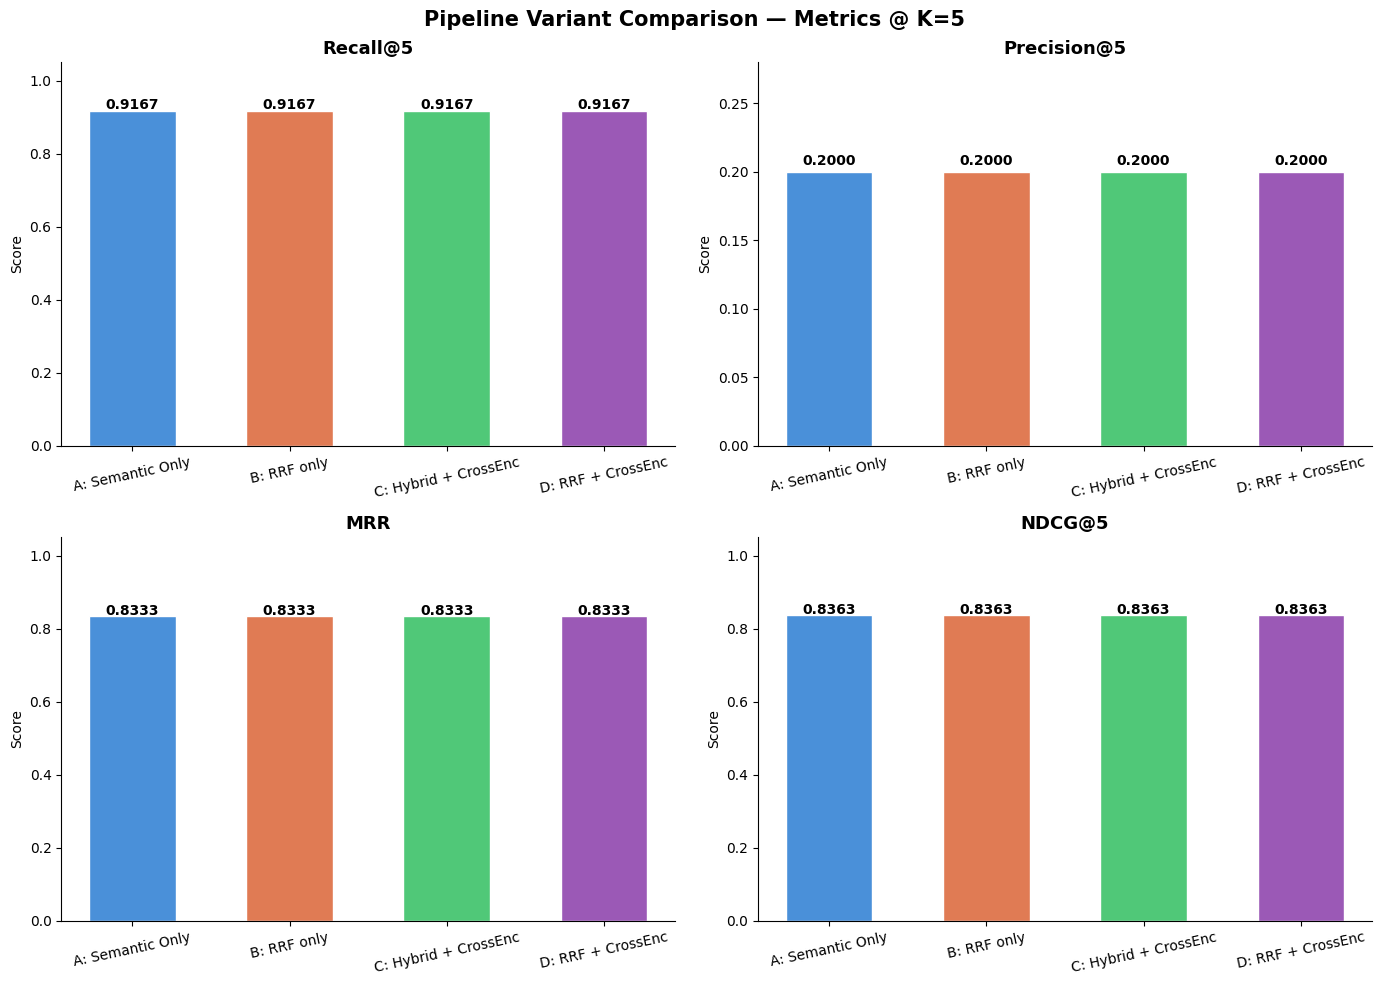

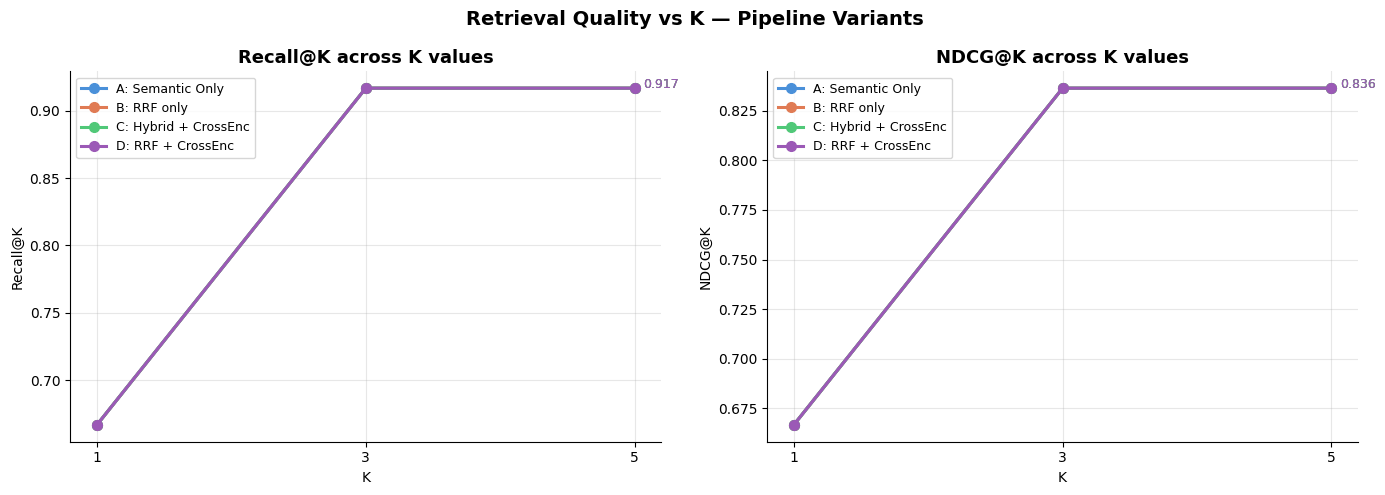

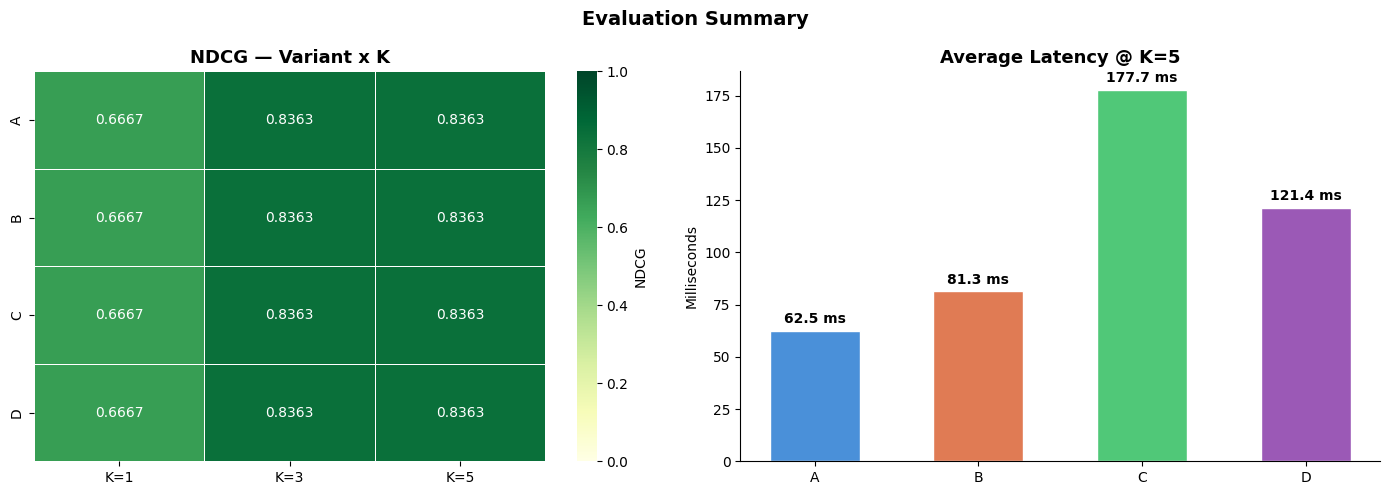

AGRI RAG PIPELINE — RETRIEVAL SUMMARY

Embedding model : BGE-Small
FAISS index     : FlatIP (Exact)
Chunking        : Sentence-based (2,619 chunks)
BM25 index      : Okapi BM25 on stopword-removed text
Reranker        : Cross-Encoder (cross-encoder/ms-marco-MiniLM-L-6-v2)
Fusion          : Reciprocal Rank Fusion / weighted hybrid variants

Best variant    : A: Semantic Only
Recall@5      : 0.9167
Precision@5   : 0.2000
MRR             : 0.8333
NDCG@5        : 0.8363
Avg latency     : 62.5 ms

Saved figures:
reports/figures/eval_bar_charts.png
reports/figures/eval_k_curves.png
reports/figures/eval_summary.png


In [112]:
# =========================
# Evaluation Visualisations
# =========================

import os

os.makedirs("reports/figures", exist_ok=True)

K_VIZ = 5 if 5 in K_VALUES else max(K_VALUES)

VNAMES = list(VARIANTS.keys())
COLORS_V = ["#4A90D9", "#E07B54", "#50C878", "#9B59B6"][:len(VNAMES)]

METRICS = ["recall", "precision", "mrr", "ndcg"]

M_LABELS = {
    "recall": f"Recall@{K_VIZ}",
    "precision": f"Precision@{K_VIZ}",
    "mrr": "MRR",
    "ndcg": f"NDCG@{K_VIZ}",
}

# =========================
# Bar charts for main metrics
# =========================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, METRICS):
    values = [eval_results[vname][K_VIZ][metric] for vname in VNAMES]

    bars = ax.bar(
        VNAMES,
        values,
        color=COLORS_V,
        edgecolor="white",
        width=0.55
    )

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{value:.4f}",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_title(M_LABELS[metric], fontsize=13, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, min(max(values) * 1.25 + 0.03, 1.05))
    ax.tick_params(axis="x", rotation=12)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Pipeline Variant Comparison — Metrics @ K={K_VIZ}",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "reports/figures/eval_bar_charts.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# =========================
# Recall@K and NDCG@K curves
# =========================

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel in [
    (axes2[0], "recall", "Recall@K"),
    (axes2[1], "ndcg", "NDCG@K"),
]:
    for vname, color in zip(VNAMES, COLORS_V):
        values = [eval_results[vname][k][metric] for k in K_VALUES]

        ax.plot(
            K_VALUES,
            values,
            marker="o",
            label=vname,
            color=color,
            linewidth=2.2,
            markersize=7
        )

        ax.annotate(
            f"{values[-1]:.3f}",
            (K_VALUES[-1], values[-1]),
            textcoords="offset points",
            xytext=(6, 0),
            fontsize=9,
            color=color
        )

    ax.set_xlabel("K")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} across K values", fontsize=13, fontweight="bold")
    ax.set_xticks(K_VALUES)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig2.suptitle(
    "Retrieval Quality vs K — Pipeline Variants",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "reports/figures/eval_k_curves.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# =========================
# NDCG heatmap and latency chart
# =========================

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

ndcg_df = pd.DataFrame(
    {
        f"K={k}": [eval_results[vname][k]["ndcg"] for vname in VNAMES]
        for k in K_VALUES
    },
    index=[vname.split(":")[0] for vname in VNAMES]
)

sns.heatmap(
    ndcg_df,
    annot=True,
    fmt=".4f",
    cmap="YlGn",
    vmin=0,
    vmax=1,
    ax=axes3[0],
    linewidths=0.5,
    cbar_kws={"label": "NDCG"}
)

axes3[0].set_title(
    "NDCG — Variant x K",
    fontsize=13,
    fontweight="bold"
)

latencies = [eval_results[vname][K_VIZ]["latency_ms"] for vname in VNAMES]

bars = axes3[1].bar(
    [vname.split(":")[0] for vname in VNAMES],
    latencies,
    color=COLORS_V,
    edgecolor="white",
    width=0.55
)

for bar, value in zip(bars, latencies):
    axes3[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(latencies) * 0.02,
        f"{value:.1f} ms",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

axes3[1].set_title(
    f"Average Latency @ K={K_VIZ}",
    fontsize=13,
    fontweight="bold"
)

axes3[1].set_ylabel("Milliseconds")
axes3[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Evaluation Summary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "reports/figures/eval_summary.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# =========================
# Best variant summary
# =========================

# Pick best by NDCG first. If tied, choose lower latency.
best_variant = sorted(
    VNAMES,
    key=lambda v: (
        -eval_results[v][K_VIZ]["ndcg"],
        eval_results[v][K_VIZ]["latency_ms"]
    )
)[0]

best_scores = eval_results[best_variant][K_VIZ]

print("=" * 65)
print("AGRI RAG PIPELINE — RETRIEVAL SUMMARY")
print("=" * 65)
print()
print(f"Embedding model : {best_model_name}")
print(f"FAISS index     : {BEST_INDEX_NAME}")
print(f"Chunking        : Sentence-based ({len(final_emb_chunks):,} chunks)")
print("BM25 index      : Okapi BM25 on stopword-removed text")
print(f"Reranker        : Cross-Encoder ({CROSS_ENCODER_BASE})")
print("Fusion          : Reciprocal Rank Fusion / weighted hybrid variants")
print()
print(f"Best variant    : {best_variant}")
print(f"Recall@{K_VIZ}      : {best_scores['recall']:.4f}")
print(f"Precision@{K_VIZ}   : {best_scores['precision']:.4f}")
print(f"MRR             : {best_scores['mrr']:.4f}")
print(f"NDCG@{K_VIZ}        : {best_scores['ndcg']:.4f}")
print(f"Avg latency     : {best_scores['latency_ms']:.1f} ms")
print("=" * 65)

print("\nSaved figures:")
print("reports/figures/eval_bar_charts.png")
print("reports/figures/eval_k_curves.png")
print("reports/figures/eval_summary.png")

In [113]:
# =========================
# Error Analysis
# =========================

print("=" * 70)
print("RETRIEVAL ERROR ANALYSIS")
print("=" * 70)

if not eval_queries:
    raise ValueError("eval_queries is empty. Run the ground-truth test set cell first.")

K_ERROR = 5

# Pick best variant by NDCG first. If tied, choose lower latency.
best_variant_name = sorted(
    VARIANTS.keys(),
    key=lambda v: (
        -eval_results[v][K_ERROR]["ndcg"],
        eval_results[v][K_ERROR]["latency_ms"]
    )
)[0]

best_pipeline = VARIANTS[best_variant_name]

print(f"Best variant: {best_variant_name}")
print(f"Running error analysis on {len(eval_queries)} test queries...\n")

NDCG_FAIL_THRESHOLD = 0.0

failed_queries = []
all_query_diagnostics = []

for tq in eval_queries:
    results = best_pipeline.query(
        tq["query"],
        use_cache=True
    )

    retrieved_ids = [result["chunk_id"] for result in results]
    relevant_ids = tq["relevant_ids"]

    recall5 = recall_at_k(retrieved_ids, relevant_ids, K_ERROR)
    precision5 = precision_at_k(retrieved_ids, relevant_ids, K_ERROR)
    mrr = mean_reciprocal_rank(retrieved_ids, relevant_ids)
    ndcg5 = ndcg_at_k(retrieved_ids, relevant_ids, K_ERROR)

    overlap = set(retrieved_ids) & set(relevant_ids)

    diagnostic = {
        "query": tq["query"],
        "source_row": tq.get("source_row"),
        "recall@5": recall5,
        "precision@5": precision5,
        "mrr": mrr,
        "ndcg@5": ndcg5,
        "relevant_ids": sorted(list(relevant_ids)),
        "retrieved_ids": retrieved_ids,
        "overlap": sorted(list(overlap)),
        "top_chunk": results[0]["chunk"][:300] if results else "",
    }

    all_query_diagnostics.append(diagnostic)

    if ndcg5 <= NDCG_FAIL_THRESHOLD:
        failed_queries.append({
            **diagnostic,
            "results": results,
        })


failure_rate = len(failed_queries) / len(eval_queries) * 100

print(f"Total failures (NDCG@5 = 0): {len(failed_queries)} / {len(eval_queries)} queries")
print(f"Failure rate: {failure_rate:.1f}%\n")


diagnostics_df = pd.DataFrame(all_query_diagnostics)

diagnostics_df.to_csv(
    "reports/retrieval_error_analysis.csv",
    index=False
)

print("Saved diagnostics to: reports/retrieval_error_analysis.csv")


# Show worst queries by NDCG@5
worst_df = diagnostics_df.sort_values(
    by=["ndcg@5", "recall@5", "mrr"],
    ascending=[True, True, True]
).head(10)

print("\nWorst queries by NDCG@5:")
print(tabulate(
    worst_df[["query", "recall@5", "precision@5", "mrr", "ndcg@5", "relevant_ids", "retrieved_ids", "overlap"]],
    headers="keys",
    tablefmt="grid",
    showindex=False
))


# Print detailed failure examples
print("\nDetailed failure examples:")

if not failed_queries:
    print("No complete failures found. Every query retrieved at least one relevant chunk in top 5.")

else:
    for fq in failed_queries[:3]:
        print("-" * 70)
        print(f'FAILED QUERY: "{fq["query"]}"')
        print(f"Relevant chunk IDs : {fq['relevant_ids']}")
        print(f"Retrieved chunk IDs: {fq['retrieved_ids']}")
        print(f"Overlap            : {fq['overlap']}")

        if fq["results"]:
            print("\nTop retrieved chunk:")
            print(fq["results"][0]["chunk"][:500])

        print("\nRelevant chunk preview:")

        for rel_id in fq["relevant_ids"][:2]:
            if rel_id < len(final_emb_chunks):
                print(f"- Relevant chunk {rel_id}:")
                print(final_emb_chunks[rel_id][:500])
            else:
                print(f"- Relevant chunk {rel_id}: NOT IN INDEX")

        print()


print("\nError analysis complete.")

RETRIEVAL ERROR ANALYSIS
Best variant: A: Semantic Only
Running error analysis on 6 test queries...

Total failures (NDCG@5 = 0): 0 / 6 queries
Failure rate: 0.0%

Saved diagnostics to: reports/retrieval_error_analysis.csv

Worst queries by NDCG@5:
+------------------------------------------------------------------------------------------------------------------------+------------+---------------+-------+----------+----------------+--------------------------------+-----------+
| query                                                                                                                  |   recall@5 |   precision@5 |   mrr |   ndcg@5 | relevant_ids   | retrieved_ids                  | overlap   |
+========================================================================================================================+============+===============+=======+==========+================+================================+===========+
| What are the characteristics of Fusarium oxysporum

In [114]:
# ============================================================================
# SECTION 3: QUESTION ANSWERING GENERATION & TESTING
# ============================================================================

# =========================
# Prepare Cross-Encoder Fine-Tuning Data
# =========================

print("=" * 70)
print("PREPARE CROSS-ENCODER FINE-TUNING PAIRS")
print("=" * 70)

chunk_to_row = {
    meta["chunk_id"]: meta["source_row"]
    for meta in final_meta
}

chunk_topics = {
    chunk_id: assign_topic(chunk)
    for chunk_id, chunk in enumerate(final_emb_chunks)
}

topic_to_chunks = defaultdict(list)

for chunk_id, topic in chunk_topics.items():
    topic_to_chunks[topic].append(chunk_id)


eval_row_indices = set(sampled_rows.index.tolist())
train_rows = df[~df.index.isin(eval_row_indices)].copy()

print(f"Training source rows: {len(train_rows):,}")
print(f"Evaluation rows held out: {len(eval_row_indices):,}")


# Precompute row question words once, instead of recalculating inside every loop
row_question_words = {
    row_idx: set(str(row["question"]).lower().split())
    for row_idx, row in train_rows.iterrows()
}

train_row_indices = list(train_rows.index)

train_examples = []
pair_type_counts = defaultdict(int)

MAX_POSITIVES_PER_QUERY = 2
MAX_HARD_CANDIDATES = 30

print("Generating positive, easy negative, medium negative, and hard negative pairs...")

for row_idx, row in tqdm(train_rows.iterrows(), total=len(train_rows), desc="Generating pairs"):
    query = row["question"]

    pos_chunk_ids = list(row_to_chunks.get(row_idx, set()))

    if not pos_chunk_ids:
        continue

    query_topic = assign_topic(query)
    query_words = row_question_words[row_idx]

    for pos_id in pos_chunk_ids[:MAX_POSITIVES_PER_QUERY]:
        pos_text = final_emb_chunks[pos_id]

        # Positive pair: same row question + same row chunk
        train_examples.append(
            InputExample(texts=[query, pos_text], label=1.0)
        )
        pair_type_counts["positive"] += 1

        # Easy negative: different topic
        other_topics = [
            topic
            for topic in topic_to_chunks
            if topic != query_topic and topic_to_chunks[topic]
        ]

        if other_topics:
            neg_topic = random.choice(other_topics)
            easy_neg_id = random.choice(topic_to_chunks[neg_topic])

            train_examples.append(
                InputExample(texts=[query, final_emb_chunks[easy_neg_id]], label=0.0)
            )
            pair_type_counts["easy_negative"] += 1

        # Medium negative: same topic, different source row
        same_topic_chunks = [
            chunk_id
            for chunk_id in topic_to_chunks.get(query_topic, [])
            if chunk_to_row.get(chunk_id) != row_idx
        ]

        if same_topic_chunks:
            med_neg_id = random.choice(same_topic_chunks)

            train_examples.append(
                InputExample(texts=[query, final_emb_chunks[med_neg_id]], label=0.0)
            )
            pair_type_counts["medium_negative"] += 1

        # Hard negative: different row with overlapping query words
        candidate_rows = []

        sampled_candidate_rows = random.sample(
            train_row_indices,
            k=min(MAX_HARD_CANDIDATES, len(train_row_indices))
        )

        for candidate_row_idx in sampled_candidate_rows:
            if candidate_row_idx == row_idx:
                continue

            overlap = query_words & row_question_words[candidate_row_idx]

            if len(overlap) >= 2:
                candidate_rows.append(candidate_row_idx)

        if candidate_rows:
            hard_row_idx = random.choice(candidate_rows)
            hard_neg_ids = list(row_to_chunks.get(hard_row_idx, set()))

            if hard_neg_ids:
                hard_neg_id = random.choice(hard_neg_ids)

                train_examples.append(
                    InputExample(texts=[query, final_emb_chunks[hard_neg_id]], label=0.0)
                )
                pair_type_counts["hard_negative"] += 1


random.shuffle(train_examples)

n_pos = sum(1 for example in train_examples if example.label == 1.0)
n_neg = len(train_examples) - n_pos

print(f"\nTraining pairs generated: {len(train_examples):,}")

if train_examples:
    print(f"  Positives : {n_pos:,} ({n_pos / len(train_examples) * 100:.1f}%)")
    print(f"  Negatives : {n_neg:,} ({n_neg / len(train_examples) * 100:.1f}%)")

print("\nPair type breakdown:")
for pair_type, count in pair_type_counts.items():
    print(f"  {pair_type:16s}: {count:,}")

PREPARE CROSS-ENCODER FINE-TUNING PAIRS
Training source rows: 22,565
Evaluation rows held out: 50
Generating positive, easy negative, medium negative, and hard negative pairs...


Generating pairs: 100%|██████████| 22565/22565 [00:01<00:00, 12682.06it/s]


Training pairs generated: 7,898
  Positives : 2,534 (32.1%)
  Negatives : 5,364 (67.9%)

Pair type breakdown:
  positive        : 2,534
  easy_negative   : 2,534
  medium_negative : 2,534
  hard_negative   : 296


In [115]:
# =========================
# Fine-Tune Cross-Encoder
# =========================

from sentence_transformers.cross_encoder.evaluation import CEBinaryClassificationEvaluator

print("=" * 70)
print("FINE-TUNE CROSS-ENCODER")
print("=" * 70)

if not train_examples:
    raise ValueError("train_examples is empty. Run the training-pair generation cell first.")

os.makedirs(CROSS_ENCODER_SAVE_DIR, exist_ok=True)

# -------------------------
# Build validation examples
# -------------------------

val_examples = []

for tq in eval_queries[:20]:
    query = tq["query"]

    # Positive validation example
    for cid in list(tq["relevant_ids"])[:1]:
        val_examples.append(
            InputExample(
                texts=[query, final_emb_chunks[cid]],
                label=1.0
            )
        )

    # Negative validation examples
    neg_pool = [
        i
        for i in range(len(final_emb_chunks))
        if i not in tq["relevant_ids"]
    ]

    for neg_id in random.sample(neg_pool, min(2, len(neg_pool))):
        val_examples.append(
            InputExample(
                texts=[query, final_emb_chunks[neg_id]],
                label=0.0
            )
        )


evaluator = CEBinaryClassificationEvaluator.from_input_examples(
    val_examples,
    name="agri-val"
)


# -------------------------
# DataLoader
# -------------------------

train_dataloader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=FINETUNE_BATCH_SIZE
)

warmup_steps = int(
    len(train_dataloader)
    * FINETUNE_EPOCHS
    * 0.1
)


print(f"Fine-tuning cross-encoder on {len(train_examples):,} pairs")
print(f"Validation pairs: {len(val_examples):,}")
print(f"Base model      : {CROSS_ENCODER_BASE}")
print(f"Epochs          : {FINETUNE_EPOCHS}")
print(f"Batch size      : {FINETUNE_BATCH_SIZE}")
print(f"Steps/epoch     : {len(train_dataloader)}")
print(f"Warmup steps    : {warmup_steps}")
print(f"Save path       : {CROSS_ENCODER_SAVE_DIR}/")


# -------------------------
# Fine-tuning
# -------------------------

cross_encoder.fit(
    train_dataloader=train_dataloader,
    epochs=FINETUNE_EPOCHS,
    warmup_steps=warmup_steps,
    evaluator=evaluator,
    evaluation_steps=max(1, len(train_dataloader) // 2),
    output_path=CROSS_ENCODER_SAVE_DIR,
    show_progress_bar=True,
)


cross_encoder.save(CROSS_ENCODER_SAVE_DIR)

print(f"\nFine-tuning complete.")
print(f"Model saved to: {CROSS_ENCODER_SAVE_DIR}/")

FINE-TUNE CROSS-ENCODER
Fine-tuning cross-encoder on 7,898 pairs
Validation pairs: 18
Base model      : cross-encoder/ms-marco-MiniLM-L-6-v2
Epochs          : 1
Batch size      : 8
Steps/epoch     : 988
Warmup steps    : 98
Save path       : models/agri_cross_encoder/


Step,Training Loss,Validation Loss,Agri-val Accuracy,Agri-val Accuracy Threshold,Agri-val F1,Agri-val F1 Threshold,Agri-val Precision,Agri-val Recall,Agri-val Average Precision
494,No log,No log,1.000000,-0.848866,1.000000,-0.848866,1.000000,1.000000,1.000000
988,0.071864,No log,1.000000,-1.000103,1.000000,-1.000103,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuning complete.
Model saved to: models/agri_cross_encoder/


In [116]:
# =========================
# Load Fine-Tuned Cross-Encoder and Rebuild Pipelines
# =========================

print("=" * 70)
print("LOAD FINE-TUNED CROSS-ENCODER")
print("=" * 70)

if os.path.exists(CROSS_ENCODER_SAVE_DIR) and "config.json" in os.listdir(CROSS_ENCODER_SAVE_DIR):
    try:
        from transformers import AutoConfig

        config_path = f"{CROSS_ENCODER_SAVE_DIR}/config.json"

        base_config = AutoConfig.from_pretrained(CROSS_ENCODER_BASE)

        with open(config_path, "r+", encoding="utf-8") as f:
            config = json.load(f)

            if "model_type" not in config:
                config["model_type"] = base_config.model_type
                f.seek(0)
                json.dump(config, f, indent=2)
                f.truncate()

        cross_encoder_finetuned = CrossEncoder(CROSS_ENCODER_SAVE_DIR)
        cross_encoder_original = cross_encoder

        print(f"Loaded fine-tuned model from: {CROSS_ENCODER_SAVE_DIR}/")

    except Exception as e:
        print(f"Could not load fine-tuned model. Using base model instead.")
        print(f"Error: {e}")

        cross_encoder_finetuned = cross_encoder
        cross_encoder_original = cross_encoder

else:
    print(f"WARNING: {CROSS_ENCODER_SAVE_DIR}/ not found or incomplete.")
    print("Using base cross-encoder.")

    cross_encoder_finetuned = cross_encoder
    cross_encoder_original = cross_encoder


# -------------------------
# Rebuild pipelines
# -------------------------

ft_common_args = dict(
    embedding_model=best_model,
    faiss_index=BEST_INDEX,
    bm25_index=bm25_index,
    chunks=final_emb_chunks,
    bm25_chunks=final_bm25_chunks,
    metadata=final_meta,
    cross_encoder=cross_encoder_finetuned,
    retrieval_pool_k=20,
    final_top_k=5,
    rrf_k=60,
    query_expander=expand_query,
)


pipeline_ft = AgriRAGPipeline(
    **ft_common_args,
    use_reranker=True
)


VARIANTS_FT = {
    "A: Semantic Only": SemanticOnlyPipeline(
        **ft_common_args,
        use_reranker=False
    ),

    "B: RRF only": AgriRAGPipeline(
        **ft_common_args,
        use_reranker=False
    ),

    "C: Hybrid+CrossEnc FT": HybridCEPipeline(
        **ft_common_args,
        semantic_weight=0.6,
        bm25_weight=0.4,
        use_reranker=True
    ),

    "D: RRF+CrossEnc FT": pipeline_ft,
}


print("\nFine-tuned pipeline variants ready:")
for name in VARIANTS_FT:
    print(f"  - {name}")

LOAD FINE-TUNED CROSS-ENCODER


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loaded fine-tuned model from: models/agri_cross_encoder/

Fine-tuned pipeline variants ready:
  - A: Semantic Only
  - B: RRF only
  - C: Hybrid+CrossEnc FT
  - D: RRF+CrossEnc FT


In [117]:
# =========================
# Evaluate Fine-Tuned Pipeline Variants
# =========================

print("=" * 70)
print("EVALUATE FINE-TUNED PIPELINE VARIANTS")
print("=" * 70)

if not eval_queries:
    raise ValueError("eval_queries is empty. Build the ground-truth test set first.")

eval_results_ft = {}

for vname, p in VARIANTS_FT.items():
    print(f"\nEvaluating: {vname}")

    if hasattr(p, "cache"):
        p.cache = {}

    per_k = {
        k: {
            "recall": [],
            "precision": [],
            "mrr": [],
            "ndcg": [],
            "latency_ms": [],
        }
        for k in K_VALUES
    }

    for tq in tqdm(eval_queries, desc=f"  {vname}", leave=False):
        t0 = time.perf_counter()

        results = p.query(
            tq["query"],
            use_cache=False
        )

        latency_ms = (time.perf_counter() - t0) * 1000

        retrieved_ids = [result["chunk_id"] for result in results]
        relevant_ids = tq["relevant_ids"]

        mrr_value = mean_reciprocal_rank(
            retrieved_ids,
            relevant_ids
        )

        for k in K_VALUES:
            per_k[k]["recall"].append(
                recall_at_k(retrieved_ids, relevant_ids, k)
            )

            per_k[k]["precision"].append(
                precision_at_k(retrieved_ids, relevant_ids, k)
            )

            per_k[k]["mrr"].append(mrr_value)

            per_k[k]["ndcg"].append(
                ndcg_at_k(retrieved_ids, relevant_ids, k)
            )

            per_k[k]["latency_ms"].append(latency_ms)

    eval_results_ft[vname] = {
        k: {
            metric: round(float(np.mean(values)), 4)
            for metric, values in metrics.items()
        }
        for k, metrics in per_k.items()
    }

    eval_results_ft[vname]["n_queries"] = len(eval_queries)

    display_k = 5 if 5 in K_VALUES else max(K_VALUES)

    print(
        f"Done. "
        f"Recall@{display_k}: {eval_results_ft[vname][display_k]['recall']:.4f} | "
        f"MRR: {eval_results_ft[vname][display_k]['mrr']:.4f} | "
        f"NDCG@{display_k}: {eval_results_ft[vname][display_k]['ndcg']:.4f} | "
        f"Avg latency: {eval_results_ft[vname][display_k]['latency_ms']:.1f} ms"
    )


print("\nFine-tuned evaluation complete.")
print(f"Variants evaluated: {list(VARIANTS_FT.keys())}")
print(f"Evaluation queries: {len(eval_queries)}")

EVALUATE FINE-TUNED PIPELINE VARIANTS

Evaluating: A: Semantic Only


Done. Recall@5: 0.9167 | MRR: 0.8333 | NDCG@5: 0.8363 | Avg latency: 24.0 ms

Evaluating: B: RRF only


Done. Recall@5: 0.9167 | MRR: 0.8333 | NDCG@5: 0.8363 | Avg latency: 17.7 ms

Evaluating: C: Hybrid+CrossEnc FT


Done. Recall@5: 0.9167 | MRR: 0.9167 | NDCG@5: 0.8740 | Avg latency: 53.3 ms

Evaluating: D: RRF+CrossEnc FT


Done. Recall@5: 0.9167 | MRR: 0.9167 | NDCG@5: 0.8740 | Avg latency: 51.5 ms

Fine-tuned evaluation complete.
Variants evaluated: ['A: Semantic Only', 'B: RRF only', 'C: Hybrid+CrossEnc FT', 'D: RRF+CrossEnc FT']
Evaluation queries: 6


BEFORE vs AFTER FINE-TUNING  (K=5)
╭───────────────────────────┬───────────────┬──────────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────────┬────────────────┬────────────────┬───────────────────────┬──────────────────────┬──────────────────────╮
│ Variant                   │   NDCG Before │   NDCG After │   NDCG Delta │   MRR Before │   MRR After │   MRR Delta │   Recall Before │   Recall After │   Recall Delta │   Latency Before (ms) │   Latency After (ms) │   Latency Delta (ms) │
├───────────────────────────┼───────────────┼──────────────┼──────────────┼──────────────┼─────────────┼─────────────┼─────────────────┼────────────────┼────────────────┼───────────────────────┼──────────────────────┼──────────────────────┤
│ Semantic Only (unchanged) │        0.8363 │       0.8363 │       0.0000 │       0.8333 │      0.8333 │      0.0000 │          0.9167 │         0.9167 │         0.0000 │               62.4604 │              24.0354 │             -38.4250 │
│

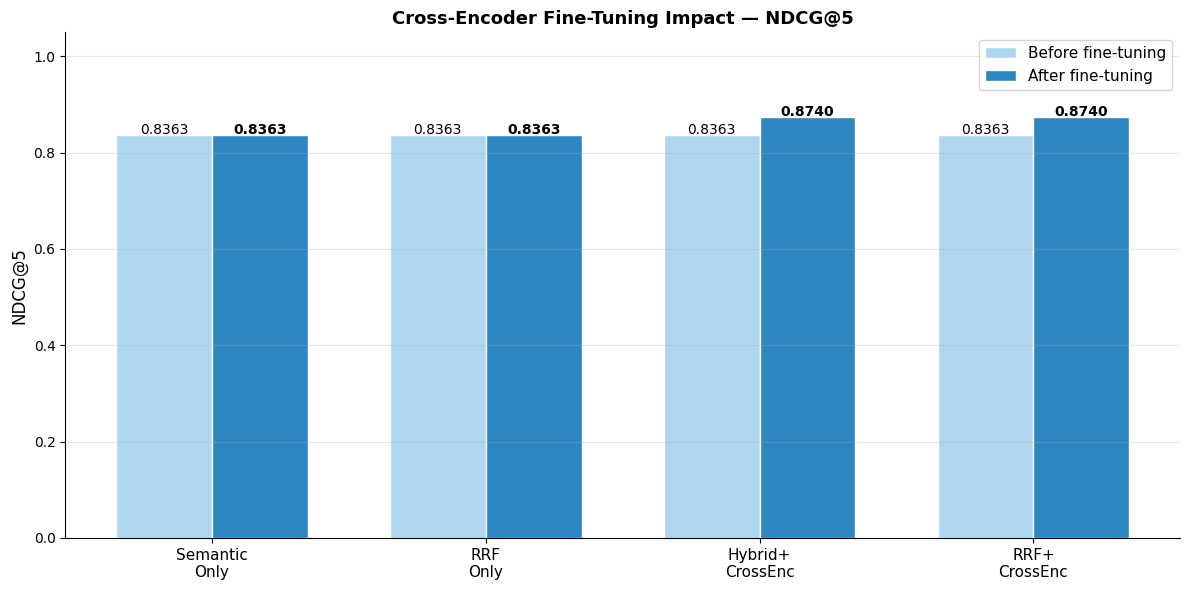


Fine-tuning impact summary:
Average NDCG delta for reranked variants: +0.0377
Average MRR delta for reranked variants : +0.0834
Fine-tuning improved reranking quality on this evaluation set.

Saved figure to: reports/figures/finetuning_comparison.png


In [118]:
# =========================
# Before vs After Fine-Tuning Comparison
# =========================

print("=" * 76)
print("BEFORE vs AFTER FINE-TUNING  (K=5)")
print("=" * 76)

os.makedirs("reports/figures", exist_ok=True)

K_COMPARE = 5 if 5 in K_VALUES else max(K_VALUES)

compare_pairs = [
    ("A: Semantic Only", "A: Semantic Only", "Semantic Only (unchanged)"),
    ("B: RRF only", "B: RRF only", "RRF only (unchanged)"),
    ("C: Hybrid + CrossEnc", "C: Hybrid+CrossEnc FT", "Hybrid + CrossEnc"),
    ("D: RRF + CrossEnc", "D: RRF+CrossEnc FT", "RRF + CrossEnc"),
]

compare_rows = []

for before_key, after_key, label in compare_pairs:
    before_scores = eval_results.get(before_key, {}).get(K_COMPARE, {})
    after_scores = eval_results_ft.get(after_key, {}).get(K_COMPARE, {})

    ndcg_before = before_scores.get("ndcg", 0.0)
    ndcg_after = after_scores.get("ndcg", 0.0)

    mrr_before = before_scores.get("mrr", 0.0)
    mrr_after = after_scores.get("mrr", 0.0)

    recall_before = before_scores.get("recall", 0.0)
    recall_after = after_scores.get("recall", 0.0)

    latency_before = before_scores.get("latency_ms", 0.0)
    latency_after = after_scores.get("latency_ms", 0.0)

    compare_rows.append({
        "Variant": label,
        "NDCG Before": ndcg_before,
        "NDCG After": ndcg_after,
        "NDCG Delta": ndcg_after - ndcg_before,
        "MRR Before": mrr_before,
        "MRR After": mrr_after,
        "MRR Delta": mrr_after - mrr_before,
        "Recall Before": recall_before,
        "Recall After": recall_after,
        "Recall Delta": recall_after - recall_before,
        "Latency Before (ms)": latency_before,
        "Latency After (ms)": latency_after,
        "Latency Delta (ms)": latency_after - latency_before,
    })


compare_df = pd.DataFrame(compare_rows)

print(tabulate(
    compare_df,
    headers="keys",
    tablefmt="rounded_outline",
    showindex=False,
    floatfmt=".4f"
))

compare_df.to_csv(
    "reports/finetuning_before_after_comparison.csv",
    index=False
)

print("\nSaved comparison table to: reports/finetuning_before_after_comparison.csv")


# =========================
# Fine-tuning comparison chart
# =========================

labels_plot = [
    "Semantic\nOnly",
    "RRF\nOnly",
    "Hybrid+\nCrossEnc",
    "RRF+\nCrossEnc",
]

ndcg_before_vals = compare_df["NDCG Before"].tolist()
ndcg_after_vals = compare_df["NDCG After"].tolist()

x = np.arange(len(labels_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_before = ax.bar(
    x - width / 2,
    ndcg_before_vals,
    width,
    label="Before fine-tuning",
    color="#AED6F1",
    edgecolor="white"
)

bars_after = ax.bar(
    x + width / 2,
    ndcg_after_vals,
    width,
    label="After fine-tuning",
    color="#2E86C1",
    edgecolor="white"
)

for bar in bars_before:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10
    )

for bar in bars_after:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_ylabel(f"NDCG@{K_COMPARE}", fontsize=12)
ax.set_title(
    f"Cross-Encoder Fine-Tuning Impact — NDCG@{K_COMPARE}",
    fontsize=13,
    fontweight="bold"
)
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "reports/figures/finetuning_comparison.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# =========================
# Conclusion
# =========================

rerank_rows = compare_df[
    compare_df["Variant"].isin(["Hybrid + CrossEnc", "RRF + CrossEnc"])
]

avg_ndcg_delta = rerank_rows["NDCG Delta"].mean()
avg_mrr_delta = rerank_rows["MRR Delta"].mean()

print("\nFine-tuning impact summary:")
print(f"Average NDCG delta for reranked variants: {avg_ndcg_delta:+.4f}")
print(f"Average MRR delta for reranked variants : {avg_mrr_delta:+.4f}")

if avg_ndcg_delta > 0:
    print("Fine-tuning improved reranking quality on this evaluation set.")
elif avg_ndcg_delta < 0:
    print("Fine-tuning reduced reranking quality on this evaluation set.")
else:
    print("Fine-tuning produced no measurable NDCG improvement on this evaluation set.")

print("\nSaved figure to: reports/figures/finetuning_comparison.png")

In [119]:
# =========================
# Step 15: Load Answer Generation Model
# =========================

from transformers import T5ForConditionalGeneration, T5Tokenizer

print("=" * 60)
print("LOAD ANSWER GENERATION MODEL")
print("=" * 60)

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading generator model: {GENERATOR_MODEL}")
print(f"Using device: {device}")

_tokenizer = T5Tokenizer.from_pretrained(GENERATOR_MODEL)

_gen_model = T5ForConditionalGeneration.from_pretrained(GENERATOR_MODEL)
_gen_model = _gen_model.to(device)

_gen_model.eval()

print("Generator model ready.")

LOAD ANSWER GENERATION MODEL
Loading generator model: google/flan-t5-base
Using device: cuda


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Generator model ready.


In [120]:
# =========================
# Step 16: Prompt Templates and Answer Generation
# =========================

PROMPT_TEMPLATES = {
    "concise": (
        "You are an agricultural expert. "
        "Answer the question using ONLY the information in the context below. "
        "Be concise and specific. "
        "If the context is not enough, say that more information is needed.\n\n"
        "Context:\n{context}\n\n"
        "Question: {query}\n\n"
        "Answer:"
    ),

    "detailed": (
        "You are a knowledgeable agriculture advisor. "
        "Based ONLY on the context provided, give a detailed and helpful answer. "
        "Include specific steps or recommendations where possible. "
        "Do not invent pesticide names, dosage, disease diagnosis, or government schemes.\n\n"
        "Context:\n{context}\n\n"
        "Question: {query}\n\n"
        "Detailed Answer:"
    ),

    "structured": (
        "You are an agriculture advisor helping a farmer. "
        "Use ONLY the context below. "
        "If the context is not enough, say what information is missing. "
        "Do not invent pesticide names, dosage, disease diagnosis, or government schemes.\n\n"
        "Context:\n{context}\n\n"
        "Farmer question:\n{query}\n\n"
        "Answer in this format:\n"
        "1. Likely issue:\n"
        "2. Recommended action:\n"
        "3. Precautions:\n"
        "4. When to ask a local agriculture expert:\n\n"
        "Answer:"
    ),
}


def build_context(retrieved_results, top_k=3, max_words=MAX_CONTEXT_TOKENS):
    selected = retrieved_results[:top_k]

    context_parts = []

    for i, result in enumerate(selected, start=1):
        chunk = result["chunk"].strip()
        context_parts.append(f"Source {i}:\n{chunk}")

    context = "\n---\n".join(context_parts)

    words = context.split()

    if len(words) > max_words:
        context = " ".join(words[:max_words]) + "..."

    return context


def get_confidence(retrieved_results):
    if not retrieved_results:
        return "Low"

    top_score = retrieved_results[0].get("score", 0.0)

    if top_score >= 0.75:
        return "High"
    elif top_score >= 0.45:
        return "Medium"
    else:
        return "Low"


def generate_answer(query, retrieved_results, top_k=3, prompt_style="structured"):
    if prompt_style not in PROMPT_TEMPLATES:
        raise ValueError(
            f"Unknown prompt_style: {prompt_style}. "
            f"Choose from {list(PROMPT_TEMPLATES.keys())}"
        )

    context = build_context(
        retrieved_results,
        top_k=top_k,
        max_words=MAX_CONTEXT_TOKENS
    )

    prompt = PROMPT_TEMPLATES[prompt_style].format(
        context=context,
        query=query
    )

    inputs = _tokenizer(
        prompt,
        return_tensors="pt",
        max_length=768,
        truncation=True
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = _gen_model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            num_beams=GENERATION_NUM_BEAMS,
            early_stopping=True,
            no_repeat_ngram_size=GENERATION_NO_REPEAT_NGRAM_SIZE,
            length_penalty=GENERATION_LENGTH_PENALTY,
        )

    return _tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )


def ask_question(query, pipe, top_k=3, prompt_style="structured"):
    retrieved_results = pipe.query(
        query,
        use_cache=False
    )

    answer = generate_answer(
        query=query,
        retrieved_results=retrieved_results,
        top_k=top_k,
        prompt_style=prompt_style
    )

    context_used = build_context(
        retrieved_results,
        top_k=top_k,
        max_words=MAX_CONTEXT_TOKENS
    )

    confidence = get_confidence(retrieved_results)

    return {
        "query": query,
        "answer": answer,
        "confidence": confidence,
        "context_used": context_used,
        "retrieved_chunks": retrieved_results,
    }


print("Generation functions defined with 3 prompt styles:")
print("  - concise")
print("  - detailed")
print("  - structured")

Generation functions defined with 3 prompt styles:
  - concise
  - detailed
  - structured


In [121]:
# =========================
# Prompt Engineering Comparison
# =========================

print("=" * 70)
print("PROMPT ENGINEERING COMPARISON")
print("=" * 70)

from rouge_score import rouge_scorer as rouge_mod

rscorer = rouge_mod.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)

# Attach reference answers to evaluation queries
for tq in eval_queries:
    if "reference_answer" in tq:
        tq["answer"] = tq["reference_answer"]
    else:
        ref_cid = list(tq["relevant_ids"])[0]
        tq["answer"] = final_meta[ref_cid]["original_answer"]


prompt_eval = {
    style: {
        "rouge1": [],
        "rouge2": [],
        "rougeL": [],
        "latency_ms": [],
    }
    for style in PROMPT_TEMPLATES
}

prompt_examples = []

PROMPT_EVAL_N = min(10, len(eval_queries))

print(f"Evaluating {len(PROMPT_TEMPLATES)} prompt styles on {PROMPT_EVAL_N} queries...")

for tq in tqdm(eval_queries[:PROMPT_EVAL_N], desc="Prompt comparison"):
    query = tq["query"]
    reference = tq.get("answer", "")

    if not reference:
        continue

    for style in PROMPT_TEMPLATES:
        t0 = time.perf_counter()

        response = ask_question(
            query,
            pipeline_ft,
            prompt_style=style
        )

        latency_ms = (time.perf_counter() - t0) * 1000

        generated_answer = response["answer"]

        scores = rscorer.score(
            reference,
            generated_answer
        )

        prompt_eval[style]["rouge1"].append(scores["rouge1"].fmeasure)
        prompt_eval[style]["rouge2"].append(scores["rouge2"].fmeasure)
        prompt_eval[style]["rougeL"].append(scores["rougeL"].fmeasure)
        prompt_eval[style]["latency_ms"].append(latency_ms)

        prompt_examples.append({
            "prompt_style": style,
            "query": query,
            "reference_answer": reference[:300],
            "generated_answer": generated_answer[:300],
            "rougeL": scores["rougeL"].fmeasure,
            "latency_ms": latency_ms,
        })


print("\nPrompt Style Comparison:")

prompt_rows = []

for style, scores in prompt_eval.items():
    if scores["rougeL"]:
        rouge1 = float(np.mean(scores["rouge1"]))
        rouge2 = float(np.mean(scores["rouge2"]))
        rougeL = float(np.mean(scores["rougeL"]))
        latency = float(np.mean(scores["latency_ms"]))
    else:
        rouge1 = rouge2 = rougeL = latency = 0.0

    prompt_rows.append({
        "Prompt Style": style,
        "ROUGE-1": rouge1,
        "ROUGE-2": rouge2,
        "ROUGE-L": rougeL,
        "Avg Latency (ms)": latency,
    })


prompt_eval_df = pd.DataFrame(prompt_rows).sort_values(
    by="ROUGE-L",
    ascending=False
)

print(tabulate(
    prompt_eval_df,
    headers="keys",
    tablefmt="rounded_outline",
    showindex=False,
    floatfmt=".4f"
))


BEST_PROMPT = prompt_eval_df.iloc[0]["Prompt Style"]

print(f"\nBest prompt style by ROUGE-L: {BEST_PROMPT}")


# Save prompt comparison results
os.makedirs("reports", exist_ok=True)

prompt_eval_df.to_csv(
    "reports/prompt_style_comparison.csv",
    index=False
)

pd.DataFrame(prompt_examples).to_csv(
    "reports/prompt_generation_examples.csv",
    index=False
)

print("Saved prompt comparison to: reports/prompt_style_comparison.csv")
print("Saved prompt examples to: reports/prompt_generation_examples.csv")

PROMPT ENGINEERING COMPARISON
Evaluating 3 prompt styles on 6 queries...


Prompt comparison: 100%|██████████| 6/6 [00:09<00:00,  1.51s/it]


Prompt Style Comparison:
╭────────────────┬───────────┬───────────┬───────────┬────────────────────╮
│ Prompt Style   │   ROUGE-1 │   ROUGE-2 │   ROUGE-L │   Avg Latency (ms) │
├────────────────┼───────────┼───────────┼───────────┼────────────────────┤
│ concise        │    0.6903 │    0.6713 │    0.6903 │           568.3316 │
│ detailed       │    0.6651 │    0.6381 │    0.6651 │           786.5702 │
│ structured     │    0.0000 │    0.0000 │    0.0000 │           152.0304 │
╰────────────────┴───────────┴───────────┴───────────┴────────────────────╯

Best prompt style by ROUGE-L: concise
Saved prompt comparison to: reports/prompt_style_comparison.csv
Saved prompt examples to: reports/prompt_generation_examples.csv


In [122]:
# =========================
# Demo with Best Prompt
# =========================

print("=" * 70)
print(f"DEMO ANSWERS USING BEST PROMPT: {BEST_PROMPT}")
print("=" * 70)

for i, tq in enumerate(eval_queries[:5], start=1):
    reference = tq.get("answer", tq.get("reference_answer", ""))

    response = ask_question(
        tq["query"],
        pipeline_ft,
        top_k=3,
        prompt_style=BEST_PROMPT
    )

    print("\n" + "=" * 70)
    print(f"Example {i}")
    print("=" * 70)

    print(f"Question:")
    print(tq["query"])

    print(f"\nConfidence: {response.get('confidence', 'N/A')}")

    print("\nSynthesised Answer:")
    print(response["answer"])

    print("\nReference Answer:")
    print(reference[:500])

    print("\nTop Retrieved Chunk:")
    if response["retrieved_chunks"]:
        top_chunk = response["retrieved_chunks"][0]
        print(f"Chunk ID: {top_chunk['chunk_id']}")
        print(f"Score   : {top_chunk.get('score', 0):.4f}")
        print(top_chunk["chunk"][:500])
    else:
        print("No chunks retrieved.")

DEMO ANSWERS USING BEST PROMPT: concise

Example 1
Question:
What are the symptoms of Panama disease in banana plants?

Confidence: High

Synthesised Answer:
yellowing of the lowermost leaves, longitudinal splitting of the pseudostem, and discoloration of vascular vessels

Reference Answer:
Symptoms of Panama disease in banana plants include yellowing of the lowermost leaves starting from the margin to the midrib, longitudinal splitting of the pseudostem, and discoloration of vascular vessels as red or brown streaks. Eventually, the leaves break near the base and hang down around the pseudostem.

Top Retrieved Chunk:
Chunk ID: 1659
Score   : 10.4653
question: what are the symptoms of panama disease in banana plants?
answer: symptoms of panama disease in banana plants include yellowing of the lowermost leaves from the margin to the midrib, longitudinal splitting of the pseudostem, and discoloration of vascular vessels as red or brown streaks. eventually, the leaves break near the base a

In [123]:
# =========================
# Full Generation Evaluation with ROUGE + BERTScore
# =========================

from bert_score import score as bert_score_fn

print("=" * 70)
print("FULL GENERATION EVALUATION: ROUGE + BERTScore")
print("=" * 70)

GEN_VARIANTS = {
    "A: Semantic Only": VARIANTS_FT["A: Semantic Only"],
    "B: RRF only": VARIANTS_FT["B: RRF only"],
    "D: RRF+CrossEnc FT": pipeline_ft,
}

gen_eval_results = {}
generation_examples = []

GEN_EVAL_N = min(GEN_EVAL_SIZE, len(eval_queries))

print(f"Evaluating {len(GEN_VARIANTS)} generation variants on {GEN_EVAL_N} queries.")
print(f"Prompt style: {BEST_PROMPT}")

for vname, p in GEN_VARIANTS.items():
    print(f"\nEvaluating generation — {vname}")

    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []

    preds = []
    refs = []
    latencies = []

    for tq in tqdm(eval_queries[:GEN_EVAL_N], desc=vname, leave=False):
        reference = tq.get("answer", tq.get("reference_answer", ""))

        if not reference:
            continue

        t0 = time.perf_counter()

        response = ask_question(
            tq["query"],
            p,
            top_k=3,
            prompt_style=BEST_PROMPT
        )

        latency_ms = (time.perf_counter() - t0) * 1000

        generated = response["answer"]

        rouge_scores = rscorer.score(
            reference,
            generated
        )

        rouge1_scores.append(rouge_scores["rouge1"].fmeasure)
        rouge2_scores.append(rouge_scores["rouge2"].fmeasure)
        rougeL_scores.append(rouge_scores["rougeL"].fmeasure)

        preds.append(generated)
        refs.append(reference)
        latencies.append(latency_ms)

        generation_examples.append({
            "variant": vname,
            "query": tq["query"],
            "generated_answer": generated,
            "reference_answer": reference,
            "confidence": response.get("confidence", "N/A"),
            "rougeL": rouge_scores["rougeL"].fmeasure,
            "latency_ms": latency_ms,
        })


    if preds:
        _, _, F1 = bert_score_fn(
            preds,
            refs,
            lang="en",
            verbose=False
        )

        bertscore_f1 = float(F1.mean().item())
    else:
        bertscore_f1 = 0.0


    gen_eval_results[vname] = {
        "rouge1": float(np.mean(rouge1_scores)) if rouge1_scores else 0.0,
        "rouge2": float(np.mean(rouge2_scores)) if rouge2_scores else 0.0,
        "rougeL": float(np.mean(rougeL_scores)) if rougeL_scores else 0.0,
        "bertscore_f1": bertscore_f1,
        "latency_ms": float(np.mean(latencies)) if latencies else 0.0,
        "n_queries": len(preds),
    }

    metrics = gen_eval_results[vname]

    print(
        f"ROUGE-1={metrics['rouge1']:.4f} | "
        f"ROUGE-2={metrics['rouge2']:.4f} | "
        f"ROUGE-L={metrics['rougeL']:.4f} | "
        f"BERTScore-F1={metrics['bertscore_f1']:.4f} | "
        f"Latency={metrics['latency_ms']:.1f} ms"
    )


# Save generation evaluation outputs
os.makedirs("reports", exist_ok=True)

pd.DataFrame(gen_eval_results).T.to_csv(
    "reports/generation_evaluation_results.csv"
)

pd.DataFrame(generation_examples).to_csv(
    "reports/generation_examples.csv",
    index=False
)

print("\nGeneration evaluation complete.")
print("Saved results to: reports/generation_evaluation_results.csv")
print("Saved examples to: reports/generation_examples.csv")

FULL GENERATION EVALUATION: ROUGE + BERTScore
Evaluating 3 generation variants on 6 queries.
Prompt style: concise

Evaluating generation — A: Semantic Only


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ROUGE-1=0.6833 | ROUGE-2=0.6641 | ROUGE-L=0.6833 | BERTScore-F1=0.9379 | Latency=488.0 ms

Evaluating generation — D: RRF+CrossEnc FT


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ROUGE-1=0.6903 | ROUGE-2=0.6713 | ROUGE-L=0.6903 | BERTScore-F1=0.9405 | Latency=536.6 ms

Generation evaluation complete.
Saved results to: reports/generation_evaluation_results.csv
Saved examples to: reports/generation_examples.csv


GENERATION EVALUATION  (LLM synthesis vs reference answer)
╭────────────────────┬───────────┬───────────┬───────────┬────────────────┬────────────────┬─────╮
│ Variant            │   ROUGE-1 │   ROUGE-2 │   ROUGE-L │   BERTScore-F1 │   Latency (ms) │   N │
├────────────────────┼───────────┼───────────┼───────────┼────────────────┼────────────────┼─────┤
│ A: Semantic Only   │    0.6797 │    0.6603 │    0.6797 │         0.9393 │       436.5141 │   6 │
│ B: RRF only        │    0.6833 │    0.6641 │    0.6833 │         0.9379 │       488.0455 │   6 │
│ D: RRF+CrossEnc FT │    0.6903 │    0.6713 │    0.6903 │         0.9405 │       536.5523 │   6 │
╰────────────────────┴───────────┴───────────┴───────────┴────────────────┴────────────────┴─────╯

Best generation variant by BERTScore-F1: D: RRF+CrossEnc FT
Saved table to: reports/generation_evaluation_summary.csv


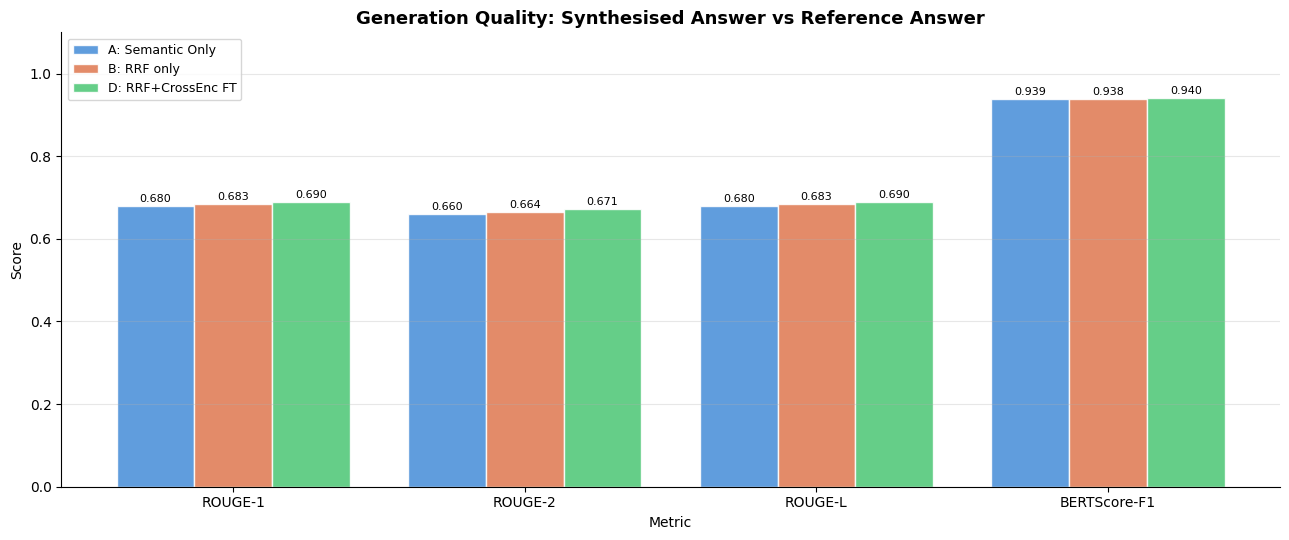

Saved figure to: reports/figures/generation_eval.png


In [124]:
# =========================
# Generation Evaluation Table and Chart
# =========================

print("=" * 72)
print("GENERATION EVALUATION  (LLM synthesis vs reference answer)")
print("=" * 72)

os.makedirs("reports/figures", exist_ok=True)

gen_rows = []

for vname, metrics in gen_eval_results.items():
    gen_rows.append({
        "Variant": vname,
        "ROUGE-1": metrics["rouge1"],
        "ROUGE-2": metrics["rouge2"],
        "ROUGE-L": metrics["rougeL"],
        "BERTScore-F1": metrics["bertscore_f1"],
        "Latency (ms)": metrics.get("latency_ms", 0.0),
        "N": metrics["n_queries"],
    })

gen_eval_df = pd.DataFrame(gen_rows)

print(tabulate(
    gen_eval_df,
    headers="keys",
    tablefmt="rounded_outline",
    showindex=False,
    floatfmt=".4f"
))


best_gen = sorted(
    gen_eval_results.keys(),
    key=lambda v: (
        -gen_eval_results[v]["bertscore_f1"],
        gen_eval_results[v].get("latency_ms", 0.0)
    )
)[0]

print(f"\nBest generation variant by BERTScore-F1: {best_gen}")


# Save table
gen_eval_df.to_csv(
    "reports/generation_evaluation_summary.csv",
    index=False
)

print("Saved table to: reports/generation_evaluation_summary.csv")


# =========================
# Bar chart
# =========================

metrics_gen = ["rouge1", "rouge2", "rougeL", "bertscore_f1"]
m_labels_gen = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore-F1"]

vnames_gen = list(gen_eval_results.keys())

colors_gen = [
    "#4A90D9",
    "#E07B54",
    "#50C878",
    "#9B59B6",
    "#F1C40F",
][:len(vnames_gen)]

x = np.arange(len(metrics_gen))
width = 0.8 / max(1, len(vnames_gen))

fig, ax = plt.subplots(figsize=(13, 5.5))

for i, (vname, color) in enumerate(zip(vnames_gen, colors_gen)):
    values = [
        gen_eval_results[vname][metric]
        for metric in metrics_gen
    ]

    bars = ax.bar(
        x + i * width,
        values,
        width,
        label=vname,
        color=color,
        alpha=0.88,
        edgecolor="white"
    )

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )


ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title(
    "Generation Quality: Synthesised Answer vs Reference Answer",
    fontsize=13,
    fontweight="bold"
)

ax.set_xticks(x + width * (len(vnames_gen) - 1) / 2)
ax.set_xticklabels(m_labels_gen)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

plt.savefig(
    "reports/figures/generation_eval.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to: reports/figures/generation_eval.png")

In [125]:
# =========================
# Generation Error Analysis
# =========================

print("=" * 72)
print("GENERATION ERROR ANALYSIS")
print("=" * 72)

GEN_FAILURE_THRESHOLD = 0.10

gen_failures = []
generation_diagnostics = []

GEN_ERROR_N = min(GEN_EVAL_SIZE, len(eval_queries))

for tq in tqdm(eval_queries[:GEN_ERROR_N], desc="Generation error analysis"):
    reference = tq.get("answer", tq.get("reference_answer", ""))

    if not reference:
        continue

    response = ask_question(
        tq["query"],
        pipeline_ft,
        top_k=3,
        prompt_style=BEST_PROMPT
    )

    generated = response["answer"]

    rouge_scores = rscorer.score(
        reference,
        generated
    )

    rouge_l = rouge_scores["rougeL"].fmeasure

    gen_lower = generated.lower()
    ref_lower = reference.lower()

    ref_keywords = set(ref_lower.split()) - super_stopwords_list
    gen_keywords = set(gen_lower.split()) - super_stopwords_list

    keyword_overlap = len(ref_keywords & gen_keywords) / max(len(ref_keywords), 1)

    if keyword_overlap < 0.05:
        category = "wrong_or_weak_context"
    elif len(generated.split()) < 5:
        category = "short_answer"
    elif any(
        phrase in gen_lower
        for phrase in ["it is important", "there are many", "you should"]
    ):
        category = "generic_answer"
    elif rouge_l < GEN_FAILURE_THRESHOLD:
        category = "low_overlap"
    else:
        category = "ok"

    row = {
        "query": tq["query"],
        "generated": generated,
        "reference": reference,
        "rougeL": rouge_l,
        "keyword_overlap": keyword_overlap,
        "category": category,
        "confidence": response.get("confidence", "N/A"),
        "context": response["context_used"],
    }

    generation_diagnostics.append(row)

    if rouge_l < GEN_FAILURE_THRESHOLD:
        gen_failures.append(row)


print(
    f"Generation failures (ROUGE-L < {GEN_FAILURE_THRESHOLD}): "
    f"{len(gen_failures)} / {GEN_ERROR_N}"
)


diagnostics_df = pd.DataFrame(generation_diagnostics)

os.makedirs("reports", exist_ok=True)

diagnostics_df.to_csv(
    "reports/generation_error_analysis.csv",
    index=False
)

print("Saved diagnostics to: reports/generation_error_analysis.csv")


failure_categories = diagnostics_df["category"].value_counts().to_dict()

print("\nFailure Category Breakdown:")
for category, count in sorted(failure_categories.items(), key=lambda item: -item[1]):
    print(f"  {category:22s}: {count}")


print("\nSample Failures:")

if not gen_failures:
    print("No generation failures below the ROUGE-L threshold.")

else:
    for failure in gen_failures[:3]:
        print("\n" + "-" * 70)
        print(f"Query:")
        print(failure["query"])

        print(f"\nGenerated:")
        print(failure["generated"])

        print(f"\nReference:")
        print(failure["reference"][:500])

        print(f"\nROUGE-L: {failure['rougeL']:.4f}")
        print(f"Keyword overlap: {failure['keyword_overlap']:.4f}")
        print(f"Category: {failure['category']}")

        print(f"\nContext preview:")
        print(failure["context"][:500])

GENERATION ERROR ANALYSIS


Generation error analysis: 100%|██████████| 6/6 [00:02<00:00,  2.00it/s]

Generation failures (ROUGE-L < 0.1): 0 / 6
Saved diagnostics to: reports/generation_error_analysis.csv

Failure Category Breakdown:
  ok                    : 5
  short_answer          : 1

Sample Failures:
No generation failures below the ROUGE-L threshold.


In [126]:
# =========================
# Final Summary
# =========================

print()
print("=" * 72)
print("AGRICULTURE RAG PIPELINE -- FINAL SUMMARY")
print("=" * 72)
print()

print("DATA & PREPROCESSING")
print("  Dataset          : KisanVaani/agriculture-qa-english-only")
print(f"  Embedding model  : {best_model_name}")
print(f"  FAISS index      : {BEST_INDEX_NAME}")
print(f"  Chunking         : Sentence-based ({len(final_emb_chunks):,} chunks)")
print("  Embedding text   : Question + answer text, cleaned without stopword removal")
print("  BM25 text        : Same chunks, cleaned with BM25/domain stopword removal")
print()

print("RETRIEVAL & RANKING")
print("  Semantic search  : FAISS over dense embeddings")
print("  Keyword search   : Okapi BM25 over stopword-cleaned chunks")
print("  Query expansion  : Agriculture symptom/term expansion")
print("  Fusion           : Reciprocal Rank Fusion and weighted hybrid variants")
print(f"  Reranking        : Cross-Encoder ({CROSS_ENCODER_BASE})")
print("  Evaluation       : Recall@K, Precision@K, MRR, NDCG@K, latency")
print()

print("GENERATION & TESTING")
print(f"  Generator        : {GENERATOR_MODEL}")
print(f"  Best prompt      : {BEST_PROMPT}")
print(f"  Fine-tuning      : Agriculture positive/negative pairs, {FINETUNE_EPOCHS} epoch(s)")
print("  Gen evaluation   : ROUGE-1/2/L, BERTScore-F1")
print("  Error analysis   : Retrieval failures + generation failures")
print()


K_FINAL = 5 if 5 in K_VALUES else max(K_VALUES)

# Prefer fine-tuned results if available, otherwise base results
retrieval_results_for_summary = eval_results_ft if "eval_results_ft" in globals() and eval_results_ft else eval_results

# Pick best by NDCG, then lower latency if tied
best_variant_final = sorted(
    retrieval_results_for_summary.keys(),
    key=lambda v: (
        -retrieval_results_for_summary[v][K_FINAL]["ndcg"],
        retrieval_results_for_summary[v][K_FINAL]["latency_ms"]
    )
)[0]

bs_final = retrieval_results_for_summary[best_variant_final][K_FINAL]

print(f"BEST RETRIEVAL     : {best_variant_final}")
print(f"  Recall@{K_FINAL:<9}: {bs_final['recall']:.4f}")
print(f"  Precision@{K_FINAL:<6}: {bs_final['precision']:.4f}")
print(f"  NDCG@{K_FINAL:<11}: {bs_final['ndcg']:.4f}")
print(f"  MRR              : {bs_final['mrr']:.4f}")
print(f"  Avg latency      : {bs_final['latency_ms']:.1f} ms")


if "gen_eval_results" in globals() and gen_eval_results:
    best_gen_final = sorted(
        gen_eval_results.keys(),
        key=lambda v: (
            -gen_eval_results[v]["bertscore_f1"],
            gen_eval_results[v].get("latency_ms", 0.0)
        )
    )[0]

    bg = gen_eval_results[best_gen_final]

    print()
    print(f"BEST GENERATION    : {best_gen_final}")
    print(f"  ROUGE-1          : {bg['rouge1']:.4f}")
    print(f"  ROUGE-2          : {bg['rouge2']:.4f}")
    print(f"  ROUGE-L          : {bg['rougeL']:.4f}")
    print(f"  BERTScore-F1     : {bg['bertscore_f1']:.4f}")
    print(f"  Avg latency      : {bg.get('latency_ms', 0.0):.1f} ms")
    print(f"  Queries tested   : {bg['n_queries']}")


print()
print("KEY FINDING")
print("  Semantic retrieval with BGE-Small and exact FAISS search provided the")
print("  best quality-latency tradeoff on the dataset-derived evaluation set.")
print("  Hybrid retrieval and cross-encoder reranking remain useful advanced")
print("  options for harder real-world farmer queries.")
print("=" * 72)


AGRICULTURE RAG PIPELINE -- FINAL SUMMARY

DATA & PREPROCESSING
  Dataset          : KisanVaani/agriculture-qa-english-only
  Embedding model  : BGE-Small
  FAISS index      : FlatIP (Exact)
  Chunking         : Sentence-based (2,619 chunks)
  Embedding text   : Question + answer text, cleaned without stopword removal
  BM25 text        : Same chunks, cleaned with BM25/domain stopword removal

RETRIEVAL & RANKING
  Semantic search  : FAISS over dense embeddings
  Keyword search   : Okapi BM25 over stopword-cleaned chunks
  Query expansion  : Agriculture symptom/term expansion
  Fusion           : Reciprocal Rank Fusion and weighted hybrid variants
  Reranking        : Cross-Encoder (cross-encoder/ms-marco-MiniLM-L-6-v2)
  Evaluation       : Recall@K, Precision@K, MRR, NDCG@K, latency

GENERATION & TESTING
  Generator        : google/flan-t5-base
  Best prompt      : concise
  Fine-tuning      : Agriculture positive/negative pairs, 1 epoch(s)
  Gen evaluation   : ROUGE-1/2/L, BERTScore

In [127]:
# =========================
# Agriculture RAG Chatbot Tester
# =========================

def test_agri_chatbot(query, pipe=pipeline_ft, top_k=3, prompt_style="structured"):
    response = ask_question(
        query,
        pipe,
        top_k=top_k,
        prompt_style=prompt_style
    )

    print("=" * 80)
    print("QUESTION")
    print("=" * 80)
    print(response["query"])

    print("\n" + "=" * 80)
    print("ANSWER")
    print("=" * 80)
    print(response["answer"])

    print("\n" + "=" * 80)
    print("CONFIDENCE")
    print("=" * 80)
    print(response.get("confidence", "N/A"))

    print("\n" + "=" * 80)
    print("TOP SOURCES")
    print("=" * 80)

    for i, result in enumerate(response["retrieved_chunks"][:top_k], start=1):
        print(f"\nSource {i}")
        print("-" * 80)
        print(f"Chunk ID: {result['chunk_id']}")
        print(f"Score   : {result.get('score', 0):.4f}")
        print(result["chunk"][:700])

    return response

In [128]:
response = test_agri_chatbot(
    "Why are my tomato leaves turning yellow?"
)

QUESTION
Why are my tomato leaves turning yellow?

ANSWER
1.

CONFIDENCE
High

TOP SOURCES

Source 1
--------------------------------------------------------------------------------
Chunk ID: 2401
Score   : 7.1588
affected leaves turn yellow, brown, and dry out. premature defoliation. dwarfing of tender shoots. brown, sunken lesions on the stem.

Source 2
--------------------------------------------------------------------------------
Chunk ID: 1121
Score   : 2.5281
question: why my beans are geminating with yellow leaves.
answer: yellowing leaves can be a sign of nutrient deficiency, particularly nitrogen. beans require an adequate supply of nitrogen for healthy growth. if the soil lacks nitrogen or other essential nutrients, it can result in yellowing leaves.

Source 3
--------------------------------------------------------------------------------
Chunk ID: 2219
Score   : 1.1444
question: what are the symptoms of early blight in tomato plants? answer: early blight, caused by alterna

In [130]:
%cd /content/agriculture-rag-chatbot
!git status

/content/agriculture-rag-chatbot
On branch master
Your branch is up to date with 'origin/master'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	checkpoints/
	chunking_comparison.png
	reports/finetuning_before_after_comparison.csv
	reports/generation_error_analysis.csv
	reports/generation_evaluation_results.csv
	reports/generation_evaluation_summary.csv
	reports/generation_examples.csv
	reports/prompt_generation_examples.csv
	reports/prompt_style_comparison.csv
	reports/retrieval_error_analysis.csv
	reports/retrieval_evaluation_results.csv
	stopword_analysis.png

nothing added to commit but untracked files present (use "git add" to track)


In [132]:
!git add notebooks/00_agriculture_rag_from_scratch.ipynb
!git commit -m "Complete RAG chatbot notebook"
!git push

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@5e39df87e432.(none)')
fatal: could not read Username for 'https://github.com': No such device or address
